# Chapter 6: Depth-Aware Learning with LiDAR Integration
## DINOv2 Fisheye Semantic Segmentation — SynWoodScape

**Sections:**
- 6.1 Motivation for Depth-Aware ADAS Perception
- 6.2 LiDAR Projection Pipeline
- 6.3 Depth Map Extraction and Alignment with RGB
- 6.4 Incorporating Depth into Training (Early / Late / Auxiliary)
- 6.5 Depth-Weighted Loss Functions
- 6.6 Experimental Results with Depth Integration
- 6.7 Impact on Near-Object Segmentation

**Model:** DINOv2 ViT-B/14 + Multi-Layer Fusion Decoder  
**Dataset:** SynWoodScape (fisheye surround-view, 4 cameras)

## 6.1 Motivation for Depth-Aware ADAS Perception

Classical semantic segmentation treats all pixels equally regardless of their real-world distance. In ADAS applications this is sub-optimal:

- **Near-range objects** (pedestrians, cyclists < 10 m) are safety-critical yet occupy comparatively few pixels in fisheye images.
- **LiDAR** provides accurate per-point 3-D distance but no texture. Cameras provide rich texture but no metric depth.
- **Sensor fusion** lets the model be explicitly penalised for errors on close objects.

### Fusion Taxonomy
| Strategy | Where depth enters | Pros | Cons |
|---|---|---|---|
| **Early fusion** | Input (RGBD concat) | End-to-end | Needs dense depth at inference |
| **Late fusion** | Loss weighting only | No inference overhead | Depth only used during training |
| **Auxiliary supervision** | Extra decoder head | Geometry-aware features | More parameters |

This notebook implements **Late Fusion** (depth-weighted loss).

## Setup — Imports, Device, Reproducibility

In [1]:
import os, json, random, glob, pickle
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple, List, Sequence

import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# Reproducibility
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_everything(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True

# ImageNet normalisation
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
_MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD_T  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
from pathlib import Path

# Paths in Google Drive
ZIP_ROOT = Path('/content/drive/MyDrive/')

RGB_ZIP = ZIP_ROOT / 'rgb_images.zip'
LABEL_ZIP = ZIP_ROOT / 'gtLabels.zip'
LIDAR_ZIP = ZIP_ROOT / 'lidar_data.zip'

# Local extraction directory (FAST)
EXTRACT_ROOT = Path('/content/datasets/synwoodscape')
RGB_DIR = EXTRACT_ROOT / 'rgb_images'
LABEL_DIR = EXTRACT_ROOT / 'gtLabels'
LIDAR_DIR = EXTRACT_ROOT / 'lidar_data'

RGB_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)
LIDAR_DIR.mkdir(parents=True, exist_ok=True)

def unzip(zip_path, extract_to):
    print(f"Unzipping {zip_path.name} → {extract_to}")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)

# Unzip only if not already extracted
if not RGB_DIR.exists() or not any(RGB_DIR.iterdir()):
    unzip(RGB_ZIP, RGB_DIR)
if not LABEL_DIR.exists() or not any(LABEL_DIR.iterdir()):
    unzip(LABEL_ZIP, LABEL_DIR)
if not LIDAR_DIR.exists() or not any(LIDAR_DIR.iterdir()):
    unzip(LIDAR_ZIP, LIDAR_DIR)



print("✅ Extraction complete")


✅ Extraction complete


In [4]:
import zipfile
from pathlib import Path

# Paths in Google Drive
ZIP_ROOT = Path('/content/drive/MyDrive/')


LABEL_ZIP = ZIP_ROOT / 'gtLabels_real.zip'


# Local extraction directory (FAST)
EXTRACT_ROOT = Path('/content/datasets/synwoodscape')

LABEL_DIR = EXTRACT_ROOT / 'gtLabels_real'


RGB_DIR.mkdir(parents=True, exist_ok=True)
LABEL_DIR.mkdir(parents=True, exist_ok=True)
LIDAR_DIR.mkdir(parents=True, exist_ok=True)

def unzip(zip_path, extract_to):
    print(f"Unzipping {zip_path.name} → {extract_to}")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)

# Unzip only if not already extracted

if not LABEL_DIR.exists() or not any(LABEL_DIR.iterdir()):
    unzip(LABEL_ZIP, LABEL_DIR)



print("✅ Extraction complete")


✅ Extraction complete


## Configuration

In [5]:
@dataclass
class Config:
    # Data
    image_dir:    str   = "/content/datasets/synwoodscape/rgb_images/rgb_images"
    mask_dir:     str   = "/content/datasets/synwoodscape/gtLabels/gtLabels"
    lidar_dir:    str   = "/content/datasets/synwoodscape/lidar_data/lidar_data/"
    calib_dir:    str   = "/content/datasets/synwoodscape/calibration/"
    images_dir:   str   = "/content/datasets/synwoodscape/rgb_images/rgb_images"
    mask_format:  str   = "auto"
    file_ext:     str   = ".png"
    max_samples:  int   = 2500
    train_ratio:  float = 0.75
    target_size:  tuple = (518, 518)
    ignore_index: int   = 255
    # Label space
    num_classes:  int   = 0
    COLOR_MAP:    dict  = None
    # Model
    model_name:            str   = "dinov2_vitb14"
    freeze_backbone:       bool  = True
    n_intermediate_layers: int   = 4
    decoder_dim:           int   = 256
    dropout:               float = 0.1
    # Training
    batch_size:        int   = 4
    epochs:            int   = 25
    lr:                float = 2e-4
    weight_decay:      float = 1e-4
    grad_accum_steps:  int   = 2
    use_amp:           bool  = True
    use_dice:          bool  = True
    dice_weight:       float = 0.3
    use_class_weights: bool  = True
    # Depth-weighted loss thresholds
    depth_near_thresh:  float = 10.0
    depth_far_thresh:   float = 30.0
    depth_near_weight:  float = 2.0
    depth_mid_weight:   float = 1.0
    depth_far_weight:   float = 0.5
    # Evaluation
    distance_bins: list = None
    camera_names:  list = None
    # Output
    out_dir: str = "/kaggle/working/checkpoints_depth_aware"

cfg = Config()
cfg.distance_bins = [0, 5, 10, 20, 30, 50, 100]
cfg.camera_names  = ["FV", "MVL", "MVR", "RV"]
os.makedirs(cfg.out_dir, exist_ok=True)

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
for k in ["image_dir","mask_dir","lidar_dir","target_size",
          "batch_size","epochs","depth_near_thresh","depth_far_thresh",
          "depth_near_weight","depth_far_weight"]:
    print(f"  {k:25s}: {getattr(cfg, k)}")
print("=" * 60)


CONFIGURATION
  image_dir                : /content/datasets/synwoodscape/rgb_images/rgb_images
  mask_dir                 : /content/datasets/synwoodscape/gtLabels/gtLabels
  lidar_dir                : /content/datasets/synwoodscape/lidar_data/lidar_data/
  target_size              : (518, 518)
  batch_size               : 4
  epochs                   : 25
  depth_near_thresh        : 10.0
  depth_far_thresh         : 30.0
  depth_near_weight        : 2.0
  depth_far_weight         : 0.5


## 6.2 LiDAR Projection Pipeline

SynWoodScape provides LiDAR point clouds in world coordinates alongside fisheye RGB images.
Each `.pkl` file contains:
```
data['points']  ->  (N, 3) float32  -- XYZ in world frame (metres)
data['labels']  ->  (N,)   int32    -- semantic class per point
```

### WoodScape Fisheye Projection Model
The polynomial fisheye model (Scaramuzza):
```
r(th) = k1*th + k2*th^2 + k3*th^3 + k4*th^4
u = cx + r(th) * (X / r_xy)
v = cy + r(th) * (Y / r_xy)
```
where `th = arctan2(r_xy, Z)` is the angle from the optical axis.

In [6]:
# Hardcoded calibrations (JSON files in calib_dir take priority)
CALIBRATIONS = {
    "FV": {
        "extrinsic": {
            "quaternion":  [0.6202204286587283, -0.6042974885762495,
                            0.36354706163082123, -0.34348900878254707],
            "translation": [1.92, 0.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 0.329055, "cy_offset": -3.5506,
            "height": 966.0, "width": 1280.0,
            "k1": 341.725, "k2": -26.4448, "k3": 32.7864, "k4": 0.50499,
        }
    },
    "MVL": {
        "extrinsic": {
            "quaternion":  [0.9625033676947315, 0.24265726834768292,
                            -0.00839554023354343, -0.12097203064563249],
            "translation": [0.8, 1.0, -0.9]
        },
        "intrinsic": {
            "cx_offset": 1.185, "cy_offset": -3.36745,
            "height": 966.0, "width": 1280.0,
            "k1": 342.234, "k2": -18.6659, "k3": 23.1572, "k4": 4.28064,
        }
    },
    "MVR": {
        "extrinsic": {
            "quaternion":  [0.2538667538615206, 0.9591523340962085,
                            -0.12402493162210342, -0.014010268296567839],
            "translation": [0.8, 1.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 0.384268, "cy_offset": -0.461036,
            "height": 966.0, "width": 1280.0,
            "k1": 340.749, "k2": -16.9704, "k3": 20.9909, "k4": 4.60924,
        }
    },
    "RV": {
        "extrinsic": {
            "quaternion":  [0.6618934113759706, 0.6615469354954553,
                            -0.24866366735447534, -0.24983823696839286],
            "translation": [-1.92, 0.0, 0.9]
        },
        "intrinsic": {
            "cx_offset": 2.86472, "cy_offset": -2.06627,
            "height": 966.0, "width": 1280.0,
            "k1": 342.457, "k2": -22.4772, "k3": 28.5462, "k4": 1.78203,
        }
    },
}


def load_calibration(camera_name: str, calib_dir: str = "") -> dict:
    """Load calibration: try JSON file first, fall back to hardcoded dict."""
    for fname in [f"{camera_name}.json", f"{camera_name.lower()}.json",
                  f"calib_{camera_name}.json"]:
        path = os.path.join(calib_dir, fname)
        if os.path.exists(path):
            with open(path) as f:
                c = json.load(f)
            extr = c.get("extrinsic", {})
            for k in list(extr.keys()):
                if "translation" in k.lower() and k != "translation":
                    extr["translation"] = extr.pop(k)
            return c
    return CALIBRATIONS.get(camera_name)


def find_image(base_name: str, camera_name: str, images_dir: str,
               exts=(".png", ".jpg", ".jpeg")) -> str:
    """Return first matching path for <base>_<cam>.<ext>, or None."""
    for ext in exts:
        p = os.path.join(images_dir, f"{base_name}_{camera_name}{ext}")
        if os.path.exists(p):
            return p
    return None


# Geometry helpers
def quaternion_to_rotation_matrix(q) -> np.ndarray:
    """Convert [w,x,y,z] quaternion to 3x3 rotation matrix."""
    w, x, y, z = q
    return np.array([
        [1 - 2*(y**2 + z**2),  2*(x*y - w*z),        2*(x*z + w*y)],
        [2*(x*y + w*z),        1 - 2*(x**2 + z**2),  2*(y*z - w*x)],
        [2*(x*z - w*y),        2*(y*z + w*x),        1 - 2*(x**2 + y**2)],
    ])


def make_transform(quaternion, translation) -> np.ndarray:
    """Build 4x4 rigid-body transform from quaternion + translation."""
    T = np.eye(4)
    T[:3, :3] = quaternion_to_rotation_matrix(quaternion)
    T[:3, 3]  = translation
    return T


def project_lidar_to_fisheye(points_world, quaternion, translation,
                              k1, k2, k3, k4, cx, cy):
    """Project Nx3 world-frame LiDAR points onto a fisheye image.
    WoodScape polynomial model: r(th)=k1*th+k2*th^2+k3*th^3+k4*th^4.
    Returns u, v, valid mask, pts_cam.
    """
    T_w2c = np.linalg.inv(make_transform(quaternion, translation))
    N     = points_world.shape[0]
    pts_h = np.hstack([points_world, np.ones((N, 1))])
    pts_c = (T_w2c @ pts_h.T).T[:, :3]

    X, Y, Z = pts_c[:, 0], pts_c[:, 1], pts_c[:, 2]
    valid   = Z > 0.1

    r_xy  = np.sqrt(X**2 + Y**2)
    theta = np.arctan2(r_xy, Z)
    r_d   = k1*theta + k2*theta**2 + k3*theta**3 + k4*theta**4

    r_safe = np.maximum(r_xy, 1e-8)
    u = cx + r_d * (X / r_safe)
    v = cy + r_d * (Y / r_safe)
    return u, v, valid, pts_c


def occlusion_filter(u, v, depth, W, H) -> np.ndarray:
    """Z-buffer: keep only the nearest LiDAR point per pixel."""
    dm   = np.full((H, W), np.inf)
    pidm = np.full((H, W), -1, dtype=int)
    ui, vi = np.round(u).astype(int), np.round(v).astype(int)
    ok   = (ui >= 0) & (ui < W) & (vi >= 0) & (vi < H)
    mask = np.zeros(len(u), dtype=bool)
    for i in np.where(ok)[0]:
        uu, vv = ui[i], vi[i]
        if depth[i] < dm[vv, uu]:
            if pidm[vv, uu] >= 0:
                mask[pidm[vv, uu]] = False
            dm[vv, uu]   = depth[i]
            pidm[vv, uu] = i
            mask[i]      = True
    return mask


print("LiDAR projection functions defined.")


LiDAR projection functions defined.


## 6.3 Depth Map Extraction and Alignment with RGB

For each LiDAR frame projected onto each camera we produce a 6-panel visualisation:
1. Depth scatter overlay on RGB
2. Semantic label scatter overlay
3. Sparse depth image (H x W, NaN where no hit)
4. Bird's-eye view (world XY)
5. Original RGB
6. Proximity-weighted scatter (point size proportional to 1/depth)

In [7]:
def process_camera(base_name, camera_name, points_world, labels,
                   calib, images_dir, output_dir):
    """Project LiDAR onto one fisheye camera. Save visualisation PNG."""
    intr = calib["intrinsic"]
    k1, k2, k3, k4 = intr["k1"], intr["k2"], intr["k3"], intr["k4"]
    cx   = intr["width"]  / 2.0 + intr["cx_offset"]
    cy   = intr["height"] / 2.0 + intr["cy_offset"]
    W, H = int(intr["width"]), int(intr["height"])

    extr        = calib["extrinsic"]
    quaternion  = extr["quaternion"]
    translation = np.array(extr["translation"])

    u, v, valid, pts_c = project_lidar_to_fisheye(
        points_world, quaternion, translation, k1, k2, k3, k4, cx, cy)
    depth = pts_c[:, 2]
    occ   = occlusion_filter(u, v, depth, W, H)
    mask  = valid & occ

    u_v, v_v = u[mask], v[mask]
    d_v      = depth[mask]
    lab_v    = labels[mask]
    pts_v    = points_world[mask]

    # Sparse depth image
    depth_img = np.full((H, W), np.nan)
    ui = np.round(u_v).astype(int)
    vi = np.round(v_v).astype(int)
    in_b = (ui >= 0) & (ui < W) & (vi >= 0) & (vi < H)
    depth_img[vi[in_b], ui[in_b]] = d_v[in_b]
    vmax = float(np.nanpercentile(d_v, 95)) if len(d_v) else 50.0

    img_path = find_image(base_name, camera_name, images_dir)
    rgb_img  = mpimg.imread(img_path) if img_path else None

    n_rows = 3 if rgb_img is not None else 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 8 * n_rows))
    fig.suptitle(f"{base_name}  |  {camera_name}", fontsize=14, fontweight="bold")

    def _bg(ax):
        ax.set_facecolor("black")
        if rgb_img is not None:
            ax.imshow(rgb_img, extent=[0, W, H, 0], aspect="auto")

    # Row 0: depth scatter | semantic scatter
    ax = axes[0, 0]; _bg(ax)
    sc = ax.scatter(u_v, v_v, c=d_v, s=2, cmap="jet", alpha=0.85, vmin=0, vmax=vmax)
    ax.set(xlim=(0, W), ylim=(H, 0), title="Depth overlay [m]",
           xlabel="u (px)", ylabel="v (px)")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, label="Depth (m)")
    ax.axhline(cy, color="w", lw=0.5, ls="--", alpha=0.4)
    ax.axvline(cx, color="w", lw=0.5, ls="--", alpha=0.4)

    ax = axes[0, 1]; _bg(ax)
    sc = ax.scatter(u_v, v_v, c=lab_v, s=2, cmap="tab20", alpha=0.85)
    ax.set(xlim=(0, W), ylim=(H, 0), title="Semantic labels",
           xlabel="u (px)", ylabel="v (px)")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, label="Label ID")

    # Row 1: sparse depth image | BEV
    ax = axes[1, 0]
    im = ax.imshow(depth_img, cmap="jet", vmin=0, vmax=vmax,
                   interpolation="nearest", aspect="auto")
    ax.set(title="Sparse depth map", xlabel="u (px)", ylabel="v (px)")
    plt.colorbar(im, ax=ax, label="Depth (m)")

    ax = axes[1, 1]
    sc = ax.scatter(pts_v[:, 0], pts_v[:, 1], c=d_v, s=1,
                    cmap="jet", alpha=0.6, vmin=0, vmax=vmax)
    ax.plot(translation[0], translation[1], "r*", ms=12, label="Camera")
    ax.set(title="Bird's-eye view (world XY)", xlabel="X (m)", ylabel="Y (m)")
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3); ax.legend()
    plt.colorbar(sc, ax=ax, label="Depth (m)")

    # Row 2: original RGB | proximity-weighted
    if rgb_img is not None:
        ax = axes[2, 0]
        ax.imshow(rgb_img); ax.set_title("Original RGB"); ax.axis("off")
        ax = axes[2, 1]; _bg(ax)
        sizes = np.clip(300 / (d_v + 1e-3), 1, 20)
        sc = ax.scatter(u_v, v_v, c=d_v, s=sizes, cmap="plasma",
                        alpha=0.9, vmin=0, vmax=vmax)
        ax.set(xlim=(0, W), ylim=(H, 0),
               title="Depth overlay (size proportional to 1/depth)")
        ax.set_aspect("equal")
        plt.colorbar(sc, ax=ax, label="Depth (m)")

    plt.tight_layout()
    out_path = os.path.join(output_dir, f"{base_name}_{camera_name}_depth.png")
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close(fig)
    print(f"  [{camera_name}] {mask.sum()} pts -> {out_path}")
    return depth_img


def run_lidar_projection(lidar_dir, images_dir, output_dir,
                         camera_names=None, max_files=3):
    """Run full LiDAR projection pipeline for up to max_files frames."""
    camera_names = camera_names or ["FV", "MVL", "MVR", "RV"]
    os.makedirs(output_dir, exist_ok=True)
    pkl_files = sorted(glob.glob(os.path.join(lidar_dir, "*.pkl")))
    if not pkl_files:
        print(f"No .pkl files found in {lidar_dir}"); return
    if max_files:
        pkl_files = pkl_files[:max_files]
    print(f"Processing {len(pkl_files)} frame(s) x {len(camera_names)} cameras")

    calibs = {}
    for cam in camera_names:
        c = load_calibration(cam, cfg.calib_dir)
        if c: calibs[cam] = c
        else: print(f"  WARNING: no calibration for {cam}")

    for pkl_path in pkl_files:
        base_name = os.path.splitext(os.path.basename(pkl_path))[0]
        print(f"\n[{base_name}]")
        with open(pkl_path, "rb") as f:
            data = pickle.load(f)
        pts_w  = data["points"]
        labels = data["labels"]

        depth_maps = {}
        for cam, calib in calibs.items():
            depth_maps[cam] = process_camera(
                base_name, cam, pts_w, labels, calib, images_dir, output_dir)

        # Summary strip
        fig, axes = plt.subplots(1, len(depth_maps), figsize=(6*len(depth_maps), 4))
        if len(depth_maps) == 1: axes = [axes]
        for ax, (cam, dm) in zip(axes, depth_maps.items()):
            vmax = float(np.nanpercentile(dm[~np.isnan(dm)], 95)) \
                   if not np.all(np.isnan(dm)) else 50.0
            im = ax.imshow(dm, cmap="jet", vmin=0, vmax=vmax,
                           interpolation="nearest", aspect="auto")
            ax.set_title(cam, fontsize=10); ax.axis("off")
            plt.colorbar(im, ax=ax, label="m", shrink=0.8)
        fig.suptitle(f"Sparse depth maps -- {base_name}", fontsize=12)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"{base_name}_summary.png"),
                    dpi=120, bbox_inches="tight")
        plt.close(fig)

    print("\nLiDAR projection complete.")


# Run on first 3 frames (set max_files=None for all)
LIDAR_OUTPUT_DIR = os.path.join(cfg.out_dir, "lidar_projection")



## Dataset Pipeline — SynWoodScape Pairs and DataLoaders

In [8]:
def list_pairs(image_dir, mask_dir,
               img_exts=(".png",".jpg",".jpeg"), mask_ext=".png"):
    """Pair RGB images with segmentation masks using recursive search."""
    image_dir, mask_dir = Path(image_dir), Path(mask_dir)
    img_files = []
    for e in img_exts:
        img_files.extend(image_dir.rglob(f"*{e}"))
    img_files = sorted(img_files)
    print(f"Found {len(img_files)} image files")
    pairs, missing = [], 0
    for img_path in img_files:
        rel = img_path.relative_to(image_dir)
        cands = [
            mask_dir / rel.with_suffix(mask_ext),
            mask_dir / rel,
            mask_dir / img_path.name,
            mask_dir / (img_path.stem + mask_ext),
        ]
        mp = next((c for c in cands if c.exists()), None)
        if mp: pairs.append((img_path, mp))
        else:  missing += 1
    if missing: print(f"  Warning: {missing} images have no matching mask")
    print(f"  Paired: {len(pairs)}")
    return pairs


def auto_detect_mask_format(mask_path):
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m is None: return "rgb"
    return "id" if m.ndim <= 2 or m.shape[2] == 1 else "rgb"


def infer_num_classes(mask_dir, file_ext=".png", ignore_index=255, max_files=100):
    files = list(Path(mask_dir).rglob(f"*{file_ext}"))[:max_files]
    mx = -1
    for f in files:
        m = cv2.imread(str(f), cv2.IMREAD_UNCHANGED)
        if m is None: continue
        if m.ndim == 3: m = m[..., 0]
        valid = m[m != ignore_index]
        if valid.size: mx = max(mx, int(valid.max()))
    return mx + 1 if mx >= 0 else 0


class PairedAugment:
    """Joint geometric + colour augmentation for image-mask pairs."""
    def __init__(self, p_flip=0.5, p_rot=0.3, max_deg=10, p_color=0.7, p_blur=0.2):
        self.p_flip=p_flip; self.p_rot=p_rot; self.max_deg=max_deg
        self.p_color=p_color; self.p_blur=p_blur

    def __call__(self, img, mask):
        if np.random.rand() < self.p_flip:
            img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
        if np.random.rand() < self.p_rot:
            angle = np.random.uniform(-self.max_deg, self.max_deg)
            h, w  = img.shape[:2]
            M     = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img   = cv2.warpAffine(img,  M, (w,h), flags=cv2.INTER_LINEAR,
                                   borderMode=cv2.BORDER_REFLECT_101)
            mask  = cv2.warpAffine(mask, M, (w,h), flags=cv2.INTER_NEAREST,
                                   borderMode=cv2.BORDER_REFLECT_101)
        if np.random.rand() < self.p_color:
            alpha = np.random.uniform(0.85, 1.15)
            beta  = np.random.uniform(-15, 15)
            img   = np.clip(alpha * img + beta, 0, 255).astype(np.uint8)
            hsv   = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
            hsv[:,:,0] = (hsv[:,:,0] + np.random.uniform(-8, 8)) % 180
            hsv[:,:,1] = np.clip(hsv[:,:,1] * np.random.uniform(0.85, 1.15), 0, 255)
            img   = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        if np.random.rand() < self.p_blur:
            k = np.random.choice([3, 5])
            img = cv2.GaussianBlur(img, (k,k), 0)
        return img, mask


class FisheyeSegDataset(Dataset):
    def __init__(self, pairs, target_size, mask_format, num_classes,
                 color_map=None, augment=False, ignore_index=255):
        self.pairs=pairs; self.target_size=target_size
        self.mask_format=mask_format; self.num_classes=num_classes
        self.color_map=color_map; self.ignore_index=ignore_index
        self.aug = PairedAugment() if augment else None

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img = np.array(Image.open(img_path).convert("RGB"))
        if self.mask_format == "rgb":
            from typing import Tuple
            msk_rgb = np.array(Image.open(mask_path).convert("RGB"))
            img     = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
            msk_rgb = cv2.resize(msk_rgb, self.target_size, interpolation=cv2.INTER_NEAREST)
            h, w, _ = msk_rgb.shape
            msk = np.full((h, w), self.ignore_index, dtype=np.int64)
            if self.color_map:
                for (r,g,b), cls in self.color_map.items():
                    m = (msk_rgb[:,:,0]==r)&(msk_rgb[:,:,1]==g)&(msk_rgb[:,:,2]==b)
                    msk[m] = cls
        else:
            m   = np.array(Image.open(mask_path))
            if m.ndim == 3: m = m[..., 0]
            img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
            m   = cv2.resize(m,   self.target_size, interpolation=cv2.INTER_NEAREST)
            msk = m.astype(np.int64)
            msk[(msk < 0) | (msk >= self.num_classes)] = self.ignore_index

        if self.aug is not None:
            img, msk = self.aug(img, msk)

        img = (img.astype(np.float32)/255.0 - IMAGENET_MEAN) / IMAGENET_STD
        img = torch.from_numpy(img.transpose(2,0,1).copy()).float().contiguous()
        msk = torch.from_numpy(msk.copy()).long().contiguous()
        return {"image": img, "mask": msk, "img_path": str(img_path)}


# Build pairs
print("\n" + "="*60 + "\nBUILDING DATASET\n" + "="*60)
all_pairs = list_pairs(cfg.image_dir, cfg.mask_dir)
if len(all_pairs) > cfg.max_samples:
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(all_pairs), size=cfg.max_samples, replace=False)
    all_pairs = [all_pairs[i] for i in idx]
    print(f"  Subsampled to {cfg.max_samples} pairs")

if cfg.mask_format == "auto":
    cfg.mask_format = auto_detect_mask_format(all_pairs[0][1])
    print(f"  Mask format: {cfg.mask_format}")

if cfg.num_classes <= 0:
    print("  Inferring num_classes ...")
    cfg.num_classes = infer_num_classes(cfg.mask_dir, cfg.file_ext, cfg.ignore_index)
    print(f"  num_classes = {cfg.num_classes}")

n       = len(all_pairs)
n_train = int(n * cfg.train_ratio)
idx     = np.arange(n)
np.random.default_rng(SEED).shuffle(idx)
train_pairs = [all_pairs[i] for i in idx[:n_train]]
test_pairs  = [all_pairs[i] for i in idx[n_train:]]
print(f"  Split: {len(train_pairs)} train / {len(test_pairs)} test")

train_ds = FisheyeSegDataset(train_pairs, cfg.target_size, cfg.mask_format,
                              cfg.num_classes, cfg.COLOR_MAP,
                              augment=True, ignore_index=cfg.ignore_index)
test_ds  = FisheyeSegDataset(test_pairs,  cfg.target_size, cfg.mask_format,
                              cfg.num_classes, cfg.COLOR_MAP,
                              augment=False, ignore_index=cfg.ignore_index)

num_workers = min(4, os.cpu_count() or 2)
pin_memory  = torch.cuda.is_available()
dl_kw = dict(num_workers=num_workers, pin_memory=pin_memory,
             persistent_workers=num_workers>0,
             prefetch_factor=2 if num_workers>0 else None)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                           drop_last=True, **dl_kw)
test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False, **dl_kw)

print(f"  Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")
print("="*60)



BUILDING DATASET
Found 2500 image files
  Paired: 2500
  Mask format: id
  Inferring num_classes ...
  num_classes = 25
  Split: 1875 train / 625 test
  Train batches: 468  |  Test batches: 157


## 6.4 Depth-Aware Model Architecture

### 6.4.1 Early Fusion
Concatenate a depth channel to RGB at the input layer. Requires dense depth at inference time — not implemented here.

### 6.4.2 Late Fusion (implemented below)
Depth enters only via the loss weighting map during training. At inference the model processes RGB only — zero overhead.

### 6.4.3 Auxiliary Depth Supervision
An additional decoder head predicts depth from the same backbone features, regularising representations to encode geometry. Left as an extension.

**Backbone:** DINOv2 ViT-B/14 (pre-trained, last 2 blocks fine-tuned)  
**Decoder:** Multi-layer fusion of last 4 intermediate layer features

In [9]:
class GNAct(nn.Module):
    """GroupNorm -> GELU -> optional Dropout2d."""
    def __init__(self, c: int, groups: int = 32, dropout: float = 0.0):
        super().__init__()
        g = min(groups, c)
        self.norm = nn.GroupNorm(num_groups=g, num_channels=c)
        self.act  = nn.GELU()
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.act(self.norm(x.contiguous())))


class MultiLayerFusionDecoder(nn.Module):
    """Fuse last N DINOv2 layer features -> pixel-level class logits."""
    def __init__(self, in_dim, n_layers, hidden, num_classes, dropout):
        super().__init__()
        self.proj = nn.ModuleList(
            [nn.Conv2d(in_dim, hidden, kernel_size=1) for _ in range(n_layers)])
        self.post = nn.Sequential(
            nn.Conv2d(hidden * n_layers, hidden, kernel_size=1),
            GNAct(hidden, dropout=dropout),
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            GNAct(hidden, dropout=dropout),
        )
        self.classifier = nn.Conv2d(hidden, num_classes, kernel_size=1)

    def forward(self, feats, target_size):
        proj   = [p(f.contiguous()) for p, f in zip(self.proj, feats)]
        x      = torch.cat(proj, dim=1).contiguous()
        x      = self.post(x)
        logits = self.classifier(x)
        return F.interpolate(logits, size=target_size,
                             mode="bilinear", align_corners=False)


class DINOv2MultiLayerSeg(nn.Module):
    """DINOv2 backbone + multi-layer fusion decoder for semantic segmentation."""
    def __init__(self, model_name, num_classes, n_layers=4, hidden=256,
                 freeze_backbone=True, dropout=0.1, pretrained=True):
        super().__init__()
        print(f"  Loading {model_name} ...")
        self.backbone   = torch.hub.load("facebookresearch/dinov2",
                                          model_name, pretrained=pretrained)
        self.patch_size = getattr(self.backbone, "patch_size", 14)
        self.embed_dim  = getattr(self.backbone, "embed_dim", 768)
        self.n_layers   = n_layers
        self.freeze_backbone = freeze_backbone

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            if hasattr(self.backbone, "blocks"):
                for blk in self.backbone.blocks[-2:]:
                    for p in blk.parameters():
                        p.requires_grad = True
            self.backbone.eval()

        self.decoder = MultiLayerFusionDecoder(
            self.embed_dim, n_layers, hidden, num_classes, dropout)

    def _to_spatial(self, t, H, W):
        Hp = H // self.patch_size
        Wp = W // self.patch_size
        return t.transpose(1,2).reshape(
            t.size(0), t.size(2), Hp, Wp).contiguous()

    def forward(self, x):
        B, C, H, W = x.shape
        feats = []
        if hasattr(self.backbone, "get_intermediate_layers"):
            with torch.set_grad_enabled(not self.freeze_backbone):
                inter = self.backbone.get_intermediate_layers(
                    x, n=self.n_layers, reshape=False, return_class_token=False)
            for t in inter:
                feats.append(t if t.dim()==4 else self._to_spatial(t, H, W))
        else:
            with torch.set_grad_enabled(not self.freeze_backbone):
                out   = self.backbone.forward_features(x)
                patch = out["x_norm_patchtokens"]
            feats = [self._to_spatial(patch, H, W)] * self.n_layers
        return self.decoder(feats, target_size=(H, W))

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_backbone: self.backbone.eval()
        return self


print("\n" + "="*60 + "\nMODEL\n" + "="*60)
model = DINOv2MultiLayerSeg(
    model_name      = cfg.model_name,
    num_classes     = cfg.num_classes,
    n_layers        = cfg.n_intermediate_layers,
    hidden          = cfg.decoder_dim,
    freeze_backbone = cfg.freeze_backbone,
    dropout         = cfg.dropout,
    pretrained      = True,
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"  Params total={total:,}  trainable={trainable:,}")
print("="*60)



MODEL
  Loading dinov2_vitb14 ...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:03<00:00, 94.1MB/s]


  Params total=88,227,865  trainable=15,826,201


## 6.5 Depth-Weighted Loss Functions

### Per-pixel weight map
```
W(u,v) = near_weight  if depth < depth_near_thresh
       = mid_weight   if near_thresh <= depth < far_thresh
       = far_weight   if depth >= far_thresh
       = 1.0          if no LiDAR hit
```

### Combined loss
```
L = (1 - w_dice) * L_CE_weighted + w_dice * L_Dice
```
Dice loss operates on the full image without depth weighting, acting as a class-balance regulariser.

In [10]:
# Class weights (inverse frequency)
def compute_class_weights(loader, num_classes, ignore_index=255, max_batches=None):
    counts = torch.zeros(num_classes, dtype=torch.long)
    for b, batch in enumerate(loader):
        m = batch["mask"]
        v = m != ignore_index
        m = m[v]
        if m.numel() > 0:
            counts += torch.bincount(m.view(-1), minlength=num_classes).cpu()
        if max_batches is not None and (b+1) >= max_batches: break
    counts = counts.float().clamp(min=1.0)
    inv = 1.0 / counts
    return inv / inv.mean()


class SoftDiceLoss(nn.Module):
    def __init__(self, num_classes, ignore_index=255, eps=1e-6):
        super().__init__()
        self.num_classes=num_classes; self.ignore_index=ignore_index; self.eps=eps

    def forward(self, logits, target):
        B, C, H, W = logits.shape
        probs = torch.softmax(logits, dim=1)
        valid = (target != self.ignore_index)
        if valid.sum() == 0: return logits.new_tensor(0.0)
        t = torch.zeros((B,C,H,W), device=logits.device, dtype=probs.dtype)
        t.scatter_(1, target.clamp(0, C-1).unsqueeze(1), 1.0)
        t     = t * valid.unsqueeze(1)
        probs = probs * valid.unsqueeze(1)
        num   = 2 * (probs * t).sum(dim=(0,2,3))
        den   = (probs + t).sum(dim=(0,2,3)) + self.eps
        dice  = 1 - (num / den)
        gt_p  = t.sum(dim=(0,2,3)) > 0
        return dice[gt_p].mean() if gt_p.any() else dice.mean()


# Confusion-matrix metrics
@torch.no_grad()
def confusion_matrix_from_logits(logits, target, num_classes, ignore_index=255):
    pred  = logits.argmax(dim=1).detach().cpu()
    tgt   = target.detach().cpu()
    valid = tgt != ignore_index
    pred  = pred[valid].reshape(-1)
    tgt   = tgt[valid].reshape(-1)
    if tgt.numel() == 0:
        return torch.zeros((num_classes, num_classes), dtype=torch.long)
    idx = tgt * num_classes + pred
    return torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)


def iou_from_confusion(cm):
    diag  = torch.diag(cm).float()
    gt    = cm.sum(dim=1).float()
    pr    = cm.sum(dim=0).float()
    denom = gt + pr - diag
    iou   = diag / torch.clamp(denom, min=1.0)
    valid = denom > 0
    miou  = iou[valid].mean().item() if valid.any() else 0.0
    pixac = (diag.sum() / torch.clamp(gt.sum(), min=1.0)).item()
    return miou, pixac, iou.cpu().numpy(), valid.cpu().numpy()


# Instantiate losses
print("Computing class weights ...")
class_weights = None
if cfg.use_class_weights:
    class_weights = compute_class_weights(train_loader, cfg.num_classes, cfg.ignore_index)
    print(f"  Top-5 weights: {class_weights[:5].tolist()}")

ce_loss   = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE) if class_weights is not None else None,
    ignore_index=cfg.ignore_index)
dice_loss = SoftDiceLoss(cfg.num_classes, ignore_index=cfg.ignore_index)


# LiDAR index for depth weight map
_pkl_index = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in sorted(glob.glob(os.path.join(cfg.lidar_dir, "*.pkl")))
}
_calibs = {cam: load_calibration(cam, cfg.calib_dir)
           for cam in cfg.camera_names
           if load_calibration(cam, cfg.calib_dir) is not None}
print(f"Depth-weight index: {len(_pkl_index)} LiDAR frames, {len(_calibs)} cameras")


def build_depth_weight_map(base_names, camera_names, img_H, img_W):
    """Build (B, H, W) float32 weight map from LiDAR depth.
    near/mid/far weights encode distance-dependent loss importance.
    """
    B          = len(base_names)
    weight_map = np.ones((B, img_H, img_W), dtype=np.float32)
    for b in range(B):
        base  = base_names[b]
        cam   = camera_names[b]
        pkl_p = _pkl_index.get(base)
        calib = _calibs.get(cam)
        if pkl_p is None or calib is None: continue
        with open(pkl_p, "rb") as f:
            data = pickle.load(f)
        pts_w = data["points"]
        intr  = calib["intrinsic"]
        k1,k2,k3,k4 = intr["k1"],intr["k2"],intr["k3"],intr["k4"]
        cx = intr["width"]/2  + intr["cx_offset"]
        cy = intr["height"]/2 + intr["cy_offset"]
        W_, H_ = int(intr["width"]), int(intr["height"])
        extr = calib["extrinsic"]
        u, v, valid, pts_c = project_lidar_to_fisheye(
            pts_w, extr["quaternion"], np.array(extr["translation"]),
            k1, k2, k3, k4, cx, cy)
        depth = pts_c[:, 2]
        occ   = occlusion_filter(u, v, depth, W_, H_)
        mask  = valid & occ
        u_v, v_v, d_v = u[mask], v[mask], depth[mask]
        ui = np.clip(np.round(u_v).astype(int), 0, img_W-1)
        vi = np.clip(np.round(v_v).astype(int), 0, img_H-1)
        w  = np.where(d_v < cfg.depth_near_thresh, cfg.depth_near_weight,
             np.where(d_v < cfg.depth_far_thresh,  cfg.depth_mid_weight,
                                                    cfg.depth_far_weight))
        weight_map[b, vi, ui] = w.astype(np.float32)
    return torch.from_numpy(weight_map)


def depth_weighted_ce_loss(logits, masks, weight_map, ignore_index=-1):
    """Per-pixel CE weighted by the LiDAR depth weight map."""
    per_pixel = F.cross_entropy(logits, masks,
                                ignore_index=ignore_index, reduction="none")
    w     = weight_map.to(per_pixel.device)
    valid = (masks != ignore_index).float()
    return (per_pixel * w * valid).sum() / valid.sum().clamp(min=1)


print("Depth-weighted loss functions ready.")


Computing class weights ...
  Top-5 weights: [8.332207679748535, 1.3546288357701997e-07, 1.1256423931627069e-05, 1.9333667751197936e-06, 3.2819186799315503e-06]
Depth-weight index: 500 LiDAR frames, 4 cameras
Depth-weighted loss functions ready.


In [11]:
DEVICE

device(type='cuda')

## 6.6 Experimental Results — Training Loop

In [12]:
# Optimiser & scheduler
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=cfg.lr, weight_decay=cfg.weight_decay)

total_steps  = cfg.epochs * max(1, len(train_loader))
warmup_steps = int(0.1 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler    = GradScaler() if cfg.use_amp else None

print(f"Optimiser: AdamW  lr={cfg.lr}  wd={cfg.weight_decay}")
print(f"Scheduler: warmup({warmup_steps} steps) + cosine decay")
print(f"AMP: {cfg.use_amp}")

best_miou  = -1.0
best_epoch = None
history    = {"epoch":[], "train_loss":[], "test_loss":[],
              "miou":[], "pixacc":[], "lr":[]}


def train_one_epoch(epoch: int) -> float:
    model.train()
    optimizer.zero_grad(set_to_none=True)
    running = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [train]")
    for it, batch in enumerate(pbar):
        img = batch["image"].to(DEVICE, non_blocking=True).contiguous()
        msk = batch["mask"].to(DEVICE, non_blocking=True).contiguous()
        B, _, H, W = img.shape

        if "base_name" in batch and "camera" in batch:
            weight_map = build_depth_weight_map(
                batch["base_name"], batch["camera"], H, W)
        else:
            weight_map = torch.ones(B, H, W, dtype=torch.float32)

        def _loss(logits):
            ce = depth_weighted_ce_loss(logits, msk, weight_map,
                                        ignore_index=cfg.ignore_index)
            if cfg.use_dice:
                return (1-cfg.dice_weight)*ce + cfg.dice_weight*dice_loss(logits, msk)
            return ce

        if cfg.use_amp:
            with autocast():
                logits = model(img)
                loss   = _loss(logits) / cfg.grad_accum_steps
            scaler.scale(loss).backward()
            if (it+1) % cfg.grad_accum_steps == 0:
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True); scheduler.step()
        else:
            logits = model(img)
            loss   = _loss(logits) / cfg.grad_accum_steps
            loss.backward()
            if (it+1) % cfg.grad_accum_steps == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True); scheduler.step()

        running += loss.item() * cfg.grad_accum_steps
        pbar.set_postfix(loss=f"{running/(it+1):.4f}",
                         lr=f"{optimizer.param_groups[0]['lr']:.2e}")
    return running / max(1, len(train_loader))


@torch.no_grad()
def evaluate():
    model.eval()
    cm = torch.zeros((cfg.num_classes, cfg.num_classes), dtype=torch.long)
    total_loss = 0.0; n = 0
    for batch in tqdm(test_loader, desc="Eval"):
        img = batch["image"].to(DEVICE, non_blocking=True)
        msk = batch["mask"].to(DEVICE, non_blocking=True)
        if cfg.use_amp:
            with autocast():
                logits = model(img)
                ce = ce_loss(logits, msk)
                loss = (1-cfg.dice_weight)*ce + cfg.dice_weight*dice_loss(logits,msk) \
                       if cfg.use_dice else ce
        else:
            logits = model(img)
            ce = ce_loss(logits, msk)
            loss = (1-cfg.dice_weight)*ce + cfg.dice_weight*dice_loss(logits,msk) \
                   if cfg.use_dice else ce
        cm += confusion_matrix_from_logits(logits, msk, cfg.num_classes, cfg.ignore_index)
        total_loss += float(loss.item()); n += 1
    miou, pixacc, per_iou, valid = iou_from_confusion(cm)
    return total_loss/max(1,n), miou, pixacc, per_iou, valid


# Training loop
print("\n" + "="*60 + "\nSTARTING TRAINING (depth-aware)\n" + "="*60)
eval_every = 5

for epoch in range(cfg.epochs):
    tr_loss = train_one_epoch(epoch)

    if epoch % eval_every == 0 or epoch == cfg.epochs - 1:
        te_loss, miou, pixacc, per_iou, valid = evaluate()
        print(f"Epoch {epoch:3d}: train={tr_loss:.4f}  test={te_loss:.4f}  "
              f"mIoU={miou:.4f}  pixAcc={pixacc:.4f}")
    else:
        te_loss, miou, pixacc = tr_loss, 0.0, 0.0
        print(f"Epoch {epoch:3d}: train={tr_loss:.4f}")

    lr_now = optimizer.param_groups[0]["lr"]
    history["epoch"].append(epoch); history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss); history["miou"].append(miou)
    history["pixacc"].append(pixacc); history["lr"].append(lr_now)

    if miou > best_miou:
        best_miou, best_epoch = miou, epoch
        ckpt = {"model": model.state_dict(), "cfg": cfg.__dict__,
                "miou": best_miou, "epoch": epoch,
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict()}
        torch.save(ckpt, os.path.join(cfg.out_dir, "best_model.pt"))
        print(f"  New best mIoU={best_miou:.4f} - checkpoint saved")

    if epoch % 10 == 0 and epoch > 0:
        torch.save({"model": model.state_dict(), "epoch": epoch, "miou": miou},
                   os.path.join(cfg.out_dir, f"checkpoint_ep{epoch}.pt"))

    if torch.cuda.is_available() and epoch % 5 == 0:
        torch.cuda.empty_cache()

print(f"\nTraining complete. Best mIoU={best_miou:.4f} at epoch {best_epoch}")
with open(os.path.join(cfg.out_dir, "training_history.json"), "w") as f:
    json.dump(history, f, indent=2)


Optimiser: AdamW  lr=0.0002  wd=0.0001
Scheduler: warmup(1170 steps) + cosine decay
AMP: True

STARTING TRAINING (depth-aware)


/tmp/ipykernel_7340/3146315618.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler() if cfg.use_amp else None


Epoch 0 [train]:   0%|          | 0/468 [00:00<?, ?it/s]

/tmp/ipykernel_7340/3146315618.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Eval:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 23 [train]:   0%|          | 0/468 [00:00<?, ?it/s]

Epoch  23: train=0.2551


Epoch 24 [train]:   0%|          | 0/468 [00:00<?, ?it/s]

Eval:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch  24: train=0.2537  test=1.0222  mIoU=0.5340  pixAcc=0.9403
  New best mIoU=0.5340 - checkpoint saved

Training complete. Best mIoU=0.5340 at epoch 24


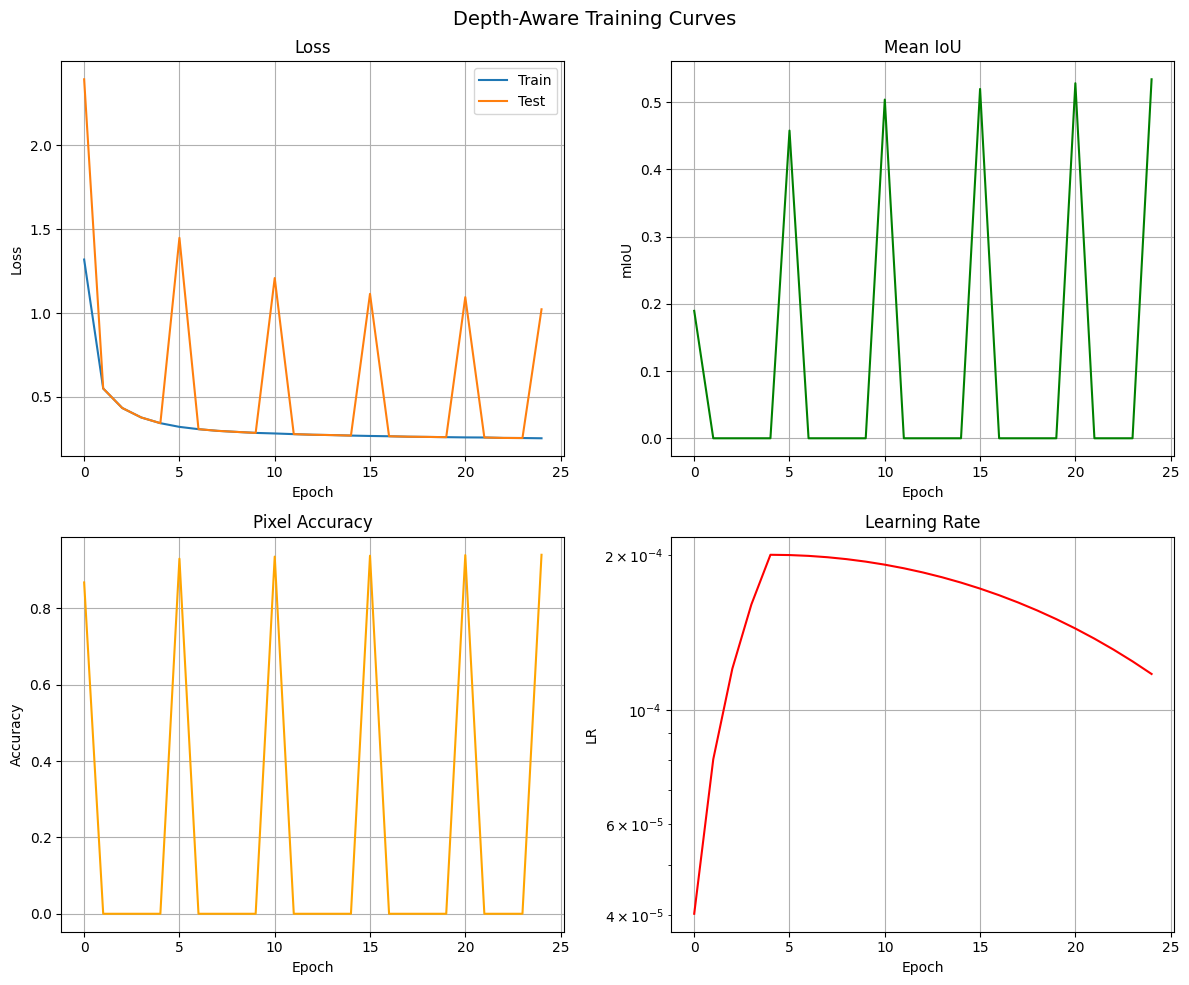

In [13]:
# Training curves
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Depth-Aware Training Curves", fontsize=14)
epochs = history["epoch"]

axes[0,0].plot(epochs, history["train_loss"], label="Train")
axes[0,0].plot(epochs, history["test_loss"],  label="Test")
axes[0,0].set(xlabel="Epoch", ylabel="Loss", title="Loss")
axes[0,0].legend(); axes[0,0].grid(True)

axes[0,1].plot(epochs, history["miou"], color="green")
axes[0,1].set(xlabel="Epoch", ylabel="mIoU", title="Mean IoU")
axes[0,1].grid(True)

axes[1,0].plot(epochs, history["pixacc"], color="orange")
axes[1,0].set(xlabel="Epoch", ylabel="Accuracy", title="Pixel Accuracy")
axes[1,0].grid(True)

axes[1,1].plot(epochs, history["lr"], color="red")
axes[1,1].set(xlabel="Epoch", ylabel="LR", title="Learning Rate")
axes[1,1].set_yscale("log"); axes[1,1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


## Qualitative Predictions

Loaded best model  epoch=24  mIoU=0.5340


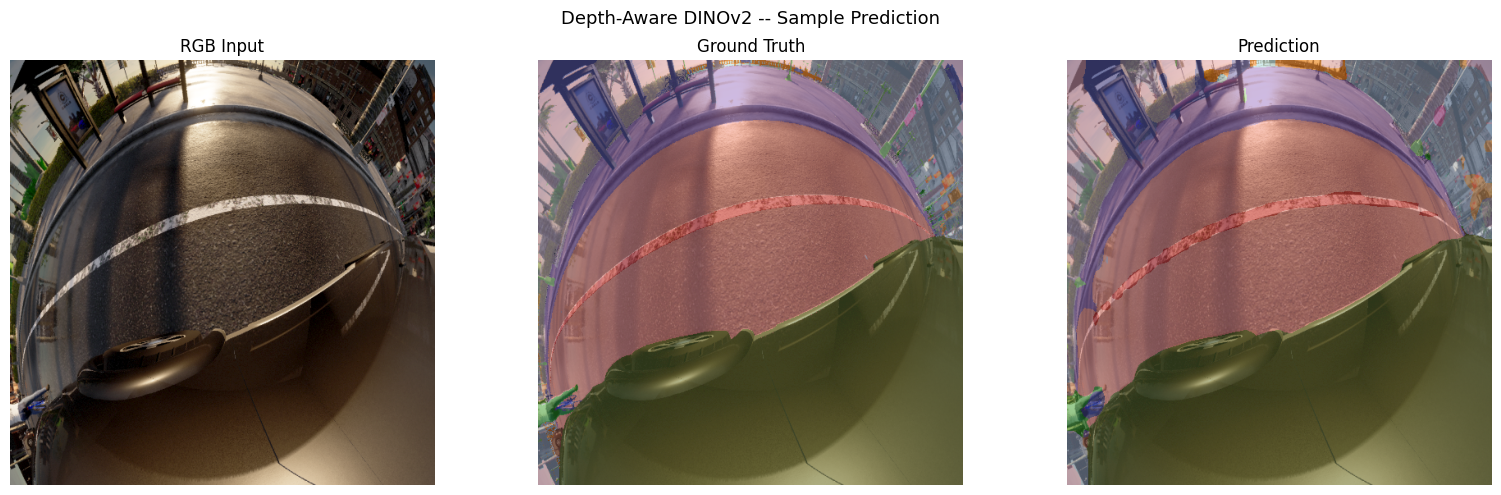

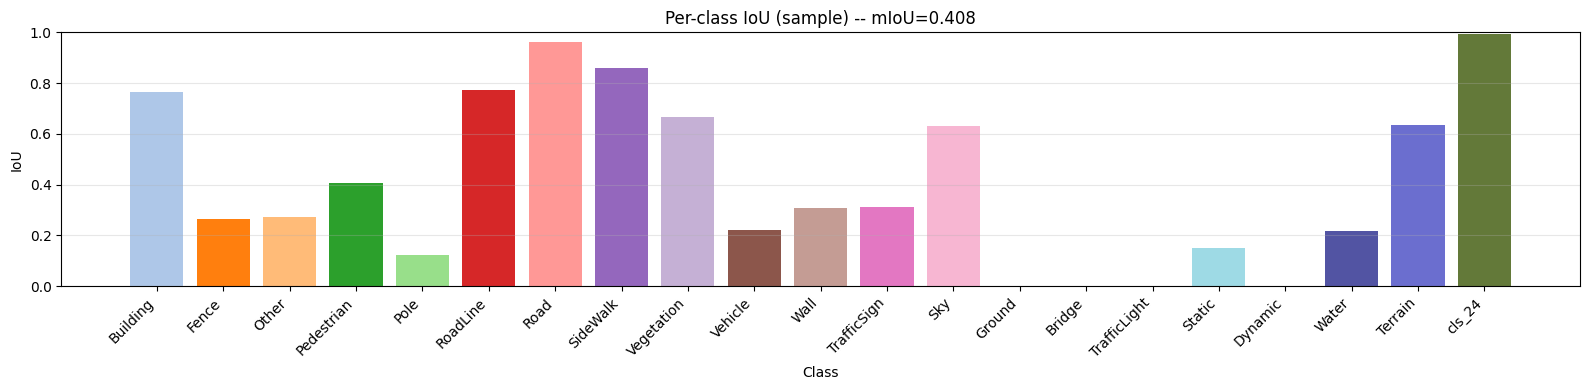

In [14]:
CARLA_CLASS_NAMES = [
    "Unlabeled","Building","Fence","Other","Pedestrian","Pole",
    "RoadLine","Road","SideWalk","Vegetation","Vehicle","Wall",
    "TrafficSign","Sky","Ground","Bridge","RailTrack","GuardRail",
    "TrafficLight","Static","Dynamic","Water","Terrain","Railway"
]


def build_palette(n):
    c1 = plt.get_cmap("tab20"); c2 = plt.get_cmap("tab20b")
    cols = [c1(i/20) for i in range(20)] + [c2(i/20) for i in range(20)]
    return np.array([list(c[:3]) for c in cols[:n]])


def colourise(label_map, palette):
    H, W = label_map.shape
    rgb  = np.zeros((H, W, 3), dtype=np.float32)
    for c in range(len(palette)):
        rgb[label_map == c] = palette[c]
    return rgb


@torch.no_grad()
def predict_mask(path_img):
    model.eval()
    img   = np.array(Image.open(path_img).convert("RGB"))
    img_r = cv2.resize(img, cfg.target_size, interpolation=cv2.INTER_LINEAR)
    x     = (img_r.astype(np.float32)/255.0 - IMAGENET_MEAN) / IMAGENET_STD
    x     = torch.from_numpy(x.transpose(2,0,1)).unsqueeze(0).to(DEVICE)
    pred  = model(x).argmax(dim=1).squeeze(0).cpu().numpy().astype(np.int32)
    return img_r, pred


def per_class_iou_single(pred, gt, num_classes, ignore_index=255):
    ious = np.full(num_classes, np.nan)
    valid = np.zeros(num_classes, dtype=bool)
    for c in range(num_classes):
        if c == ignore_index: continue
        inter = np.logical_and(pred==c, gt==c).sum()
        union = np.logical_or(pred==c, gt==c).sum()
        if union > 0:
            ious[c]  = inter / union
            valid[c] = True
    return ious, valid


# Load best checkpoint
ckpt = torch.load(os.path.join(cfg.out_dir, "best_model.pt"),
                   map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded best model  epoch={ckpt['epoch']}  mIoU={ckpt['miou']:.4f}")

palette = build_palette(cfg.num_classes)

img_path, mask_path = test_pairs[0]
img_r, pred = predict_mask(str(img_path))

gt_raw = np.array(Image.open(mask_path))
if gt_raw.ndim == 3: gt_raw = gt_raw[..., 0]
gt = cv2.resize(gt_raw, cfg.target_size, interpolation=cv2.INTER_NEAREST).astype(np.int32)

# 3-panel visualisation
def blend(label):
    return np.clip(img_r.astype(np.float32)/255 * 0.55
                   + colourise(label, palette) * 0.45, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Depth-Aware DINOv2 -- Sample Prediction", fontsize=13)
axes[0].imshow(img_r);       axes[0].set_title("RGB Input");    axes[0].axis("off")
axes[1].imshow(blend(gt));   axes[1].set_title("Ground Truth"); axes[1].axis("off")
axes[2].imshow(blend(pred)); axes[2].set_title("Prediction");   axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "sample_prediction.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Per-class IoU bar chart
ious, valid = per_class_iou_single(pred, gt, cfg.num_classes, cfg.ignore_index)
class_ids   = np.where(valid)[0]
labels_str  = [CARLA_CLASS_NAMES[i] if i < len(CARLA_CLASS_NAMES) else f"cls_{i}"
               for i in class_ids]

plt.figure(figsize=(16, 4))
plt.bar(range(len(class_ids)), ious[class_ids],
        color=[palette[i % len(palette)] for i in class_ids])
plt.xticks(range(len(class_ids)), labels_str, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.xlabel("Class"); plt.ylabel("IoU")
plt.title(f"Per-class IoU (sample) -- mIoU={np.nanmean(ious):.3f}")
plt.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "per_class_iou_sample.png"),
            dpi=150, bbox_inches="tight")
plt.show()


Eval:   0%|          | 0/157 [00:00<?, ?it/s]

/tmp/ipykernel_7340/3146315618.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


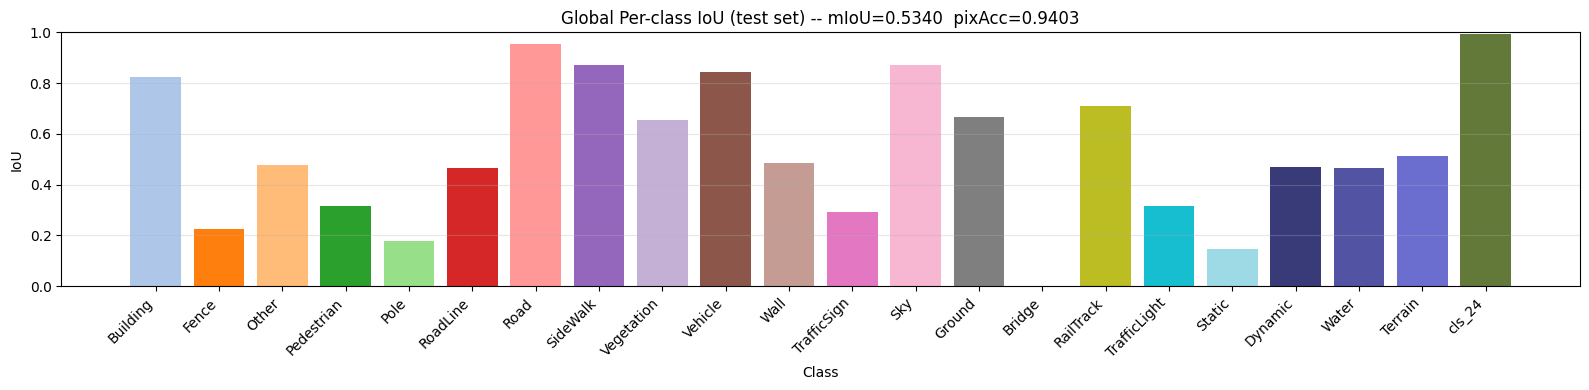

Final test mIoU   : 0.5340
Final test pixAcc : 0.9403


In [15]:
# Global per-class IoU on full test set
te_loss_f, miou_f, pixacc_f, per_iou_f, valid_f = evaluate()

class_ids_g = np.where(valid_f)[0]
labels_g    = [CARLA_CLASS_NAMES[i] if i < len(CARLA_CLASS_NAMES) else f"cls_{i}"
               for i in class_ids_g]

plt.figure(figsize=(16, 4))
plt.bar(range(len(class_ids_g)), per_iou_f[class_ids_g],
        color=[palette[i % len(palette)] for i in class_ids_g])
plt.xticks(range(len(class_ids_g)), labels_g, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.xlabel("Class"); plt.ylabel("IoU")
plt.title(f"Global Per-class IoU (test set) -- mIoU={miou_f:.4f}  pixAcc={pixacc_f:.4f}")
plt.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "global_per_class_iou.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Final test mIoU   : {miou_f:.4f}")
print(f"Final test pixAcc : {pixacc_f:.4f}")


## 6.6 Distance vs Accuracy Evaluation

Segmentation quality (mIoU, pixel accuracy, per-class IoU) as a function of metric depth:
1. Run inference on each test frame
2. Project the LiDAR cloud onto the image
3. Sample predicted and GT labels at each projected point
4. Bin by distance and compute confusion matrices per bin

In [ ]:
class DistanceMetrics:
    """Per-distance-bin confusion matrix accumulator."""
    def __init__(self, bins, num_classes):
        self.edges  = np.array(bins, dtype=np.float32)
        self.n_bins = len(bins) - 1
        self.K      = num_classes
        self.conf   = np.zeros((self.n_bins, num_classes, num_classes), dtype=np.int64)
        self.counts = np.zeros(self.n_bins, dtype=np.int64)

    def update(self, gt_labels, pred_labels, depths):
        bin_idx = np.searchsorted(self.edges[1:-1], depths)
        valid   = ((gt_labels >= 0) & (gt_labels < self.K) &
                   (pred_labels >= 0) & (pred_labels < self.K) &
                   np.isfinite(depths))
        for b in range(self.n_bins):
            m = valid & (bin_idx == b)
            if not m.any(): continue
            np.add.at(self.conf[b], (gt_labels[m], pred_labels[m]), 1)
            self.counts[b] += m.sum()

    def pixel_accuracy(self):
        acc = np.full(self.n_bins, np.nan)
        for b in range(self.n_bins):
            tot = self.conf[b].sum()
            if tot > 0: acc[b] = self.conf[b].diagonal().sum() / tot
        return acc

    def per_class_iou(self):
        iou = np.full((self.n_bins, self.K), np.nan)
        for b in range(self.n_bins):
            C = self.conf[b]
            for c in range(self.K):
                tp    = C[c, c]
                denom = tp + C[:,c].sum() - tp + C[c,:].sum() - tp
                if denom > 0: iou[b, c] = tp / denom
        return iou

    def miou(self): return np.nanmean(self.per_class_iou(), axis=1)

    def bin_labels(self):
        e = self.edges
        return [f"{e[i]:.0f}-{e[i+1]:.0f} m" for i in range(self.n_bins)]


PATCH = 14  # DINOv2 patch size

def make_divisible(x, div=PATCH):
    """Round x down to nearest multiple of div."""
    return (x // div) * div

def _load_img_tensor(path):
    img = mpimg.imread(path)
    if img.dtype == np.uint8: img = img.astype(np.float32) / 255.0
    if img.ndim == 2:         img = np.stack([img]*3, -1)
    img = img[:, :, :3]
    orig_H, orig_W = img.shape[:2]

    # ── Snap to multiples of patch size ──────────────────────────
    new_H = make_divisible(orig_H)
    new_W = make_divisible(orig_W)
    if new_H != orig_H or new_W != orig_W:
        img = cv2.resize(img, (new_W, new_H), interpolation=cv2.INTER_LINEAR)
    # ─────────────────────────────────────────────────────────────

    t = torch.from_numpy(img.transpose(2,0,1)).float()
    t = ((t - _MEAN_T) / _STD_T).unsqueeze(0).to(DEVICE)
    return t, orig_H, orig_W   # return ORIGINAL dims for upsampling back


@torch.no_grad()
def _run_inference(img_tensor, orig_H, orig_W):
    logits = model(img_tensor)
    if logits.shape[-2:] != (orig_H, orig_W):
        logits = F.interpolate(logits, size=(orig_H, orig_W),
                               mode="bilinear", align_corners=False)
    return logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.int32)


# Run evaluation
print("\n" + "="*60 + "\nDISTANCE vs ACCURACY EVALUATION\n" + "="*60)
metrics   = DistanceMetrics(cfg.distance_bins, cfg.num_classes)
pkl_files = sorted(glob.glob(os.path.join(cfg.lidar_dir, "*.pkl")))
print(f"LiDAR frames: {len(pkl_files)}  |  Cameras: {list(_calibs.keys())}")

for pkl_path in tqdm(pkl_files, desc="Distance eval"):
    base = os.path.splitext(os.path.basename(pkl_path))[0]
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    pts_w  = data["points"]
    labels = data["labels"]

    for cam, calib in _calibs.items():
        img_path = find_image(base, cam, cfg.images_dir)
        if img_path is None: continue
        try:
            img_t, orig_H, orig_W = _load_img_tensor(img_path)
            pred_map = _run_inference(img_t, orig_H, orig_W)
        except Exception as e:
            tqdm.write(f"  WARN {base} {cam}: {e}"); continue

        intr = calib["intrinsic"]
        k1,k2,k3,k4 = intr["k1"],intr["k2"],intr["k3"],intr["k4"]
        cx = intr["width"]/2 + intr["cx_offset"]
        cy = intr["height"]/2 + intr["cy_offset"]
        W_, H_ = int(intr["width"]), int(intr["height"])
        extr = calib["extrinsic"]

        u, v, valid, pts_c = project_lidar_to_fisheye(
            pts_w, extr["quaternion"], np.array(extr["translation"]),
            k1, k2, k3, k4, cx, cy)
        depth = pts_c[:, 2]
        occ   = occlusion_filter(u, v, depth, W_, H_)
        mask  = valid & occ

        u_v, v_v = u[mask], v[mask]
        d_v      = depth[mask]
        gt_v     = labels[mask].astype(np.int32)
        if len(gt_v) == 0: continue

        ui = np.clip(np.round(u_v).astype(int), 0, orig_W-1)
        vi = np.clip(np.round(v_v).astype(int), 0, orig_H-1)
        metrics.update(gt_v, pred_map[vi, ui], d_v)

print("Distance evaluation complete.")



Bin                 Points   PixAcc     mIoU
0-5 m            8,122,027   0.3073   0.0202
5-10 m           2,103,306   0.1763   0.0161
10-20 m          1,251,001   0.1127   0.0106
20-30 m            565,232   0.0611   0.0057
30-50 m            496,038   0.0298   0.0038
50-100 m           502,468   0.0149   0.0016
CSV saved: /kaggle/working/checkpoints_depth_aware/distance_accuracy.csv


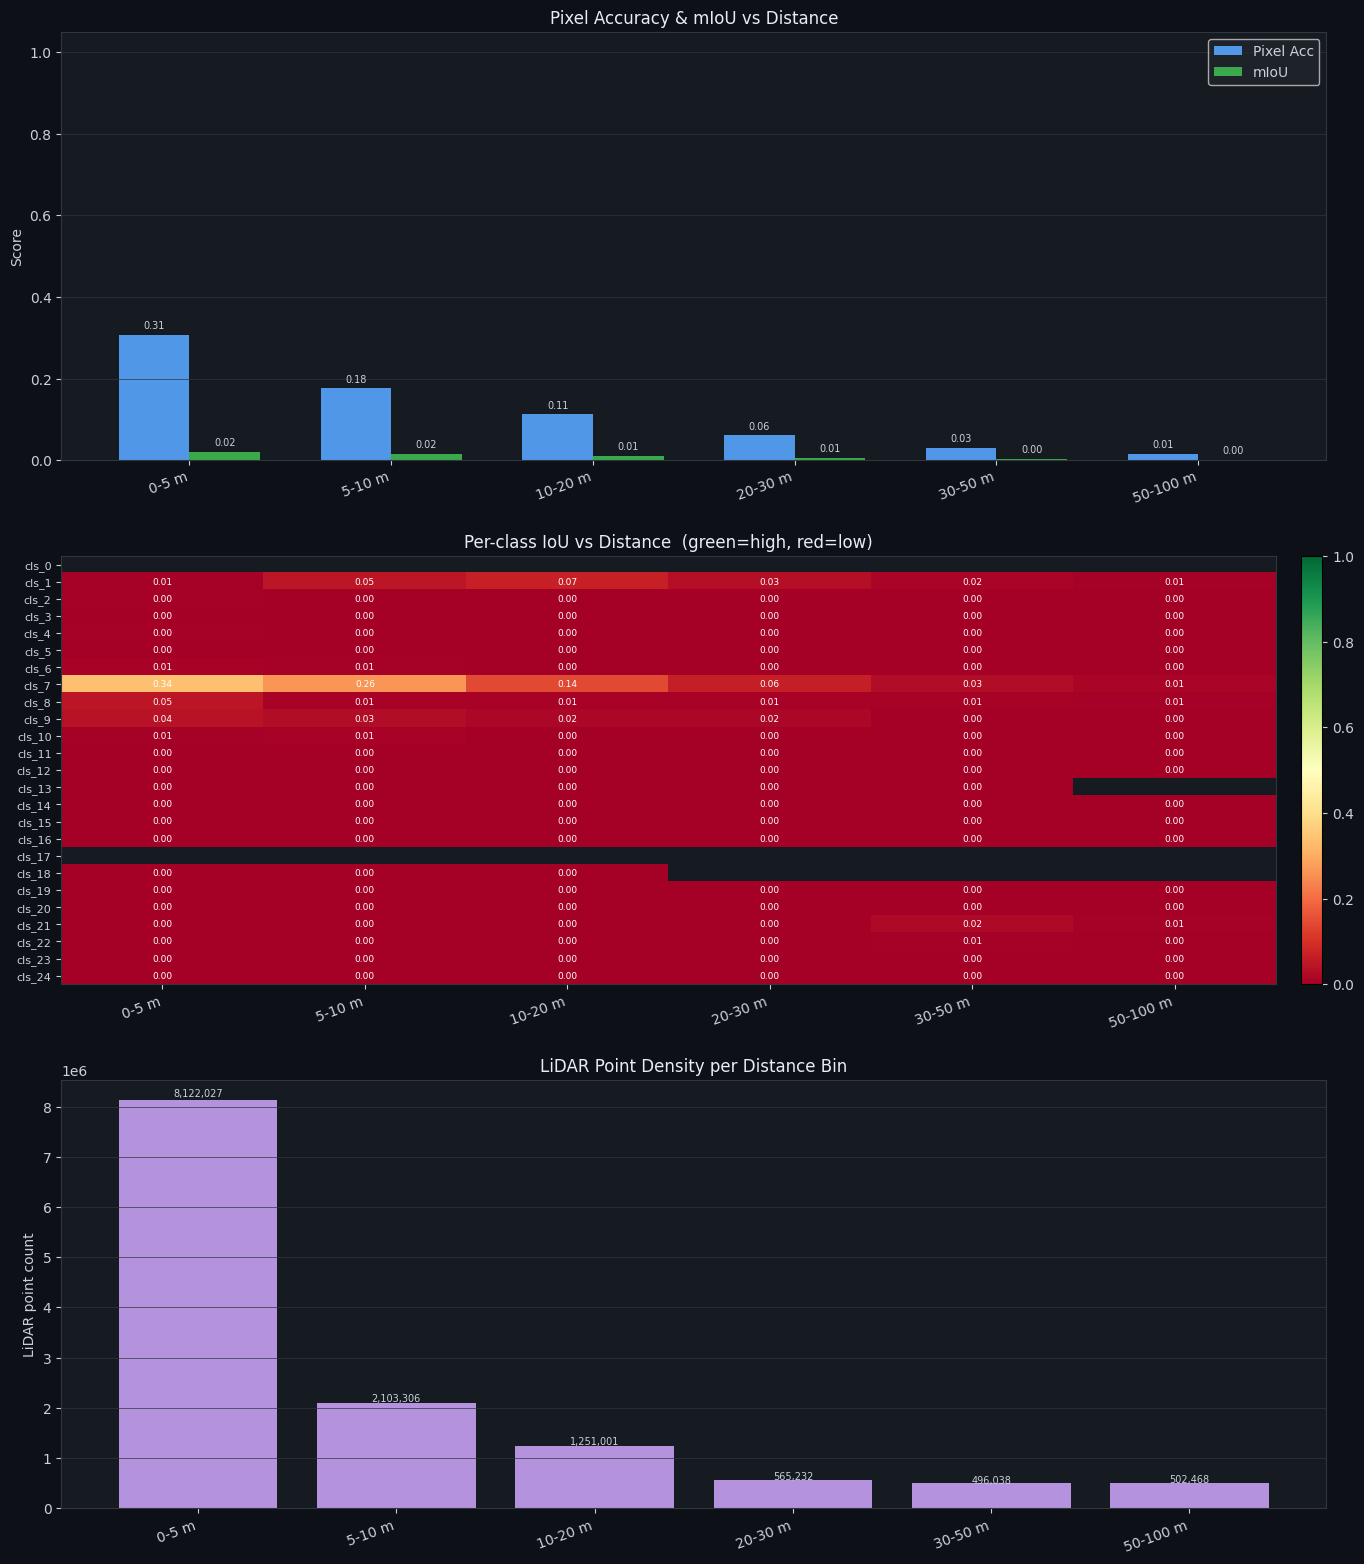

Plot saved: /kaggle/working/checkpoints_depth_aware/distance_vs_accuracy.png


In [18]:
# Aggregate results
bin_labels  = metrics.bin_labels()
acc         = metrics.pixel_accuracy()
miou_vals   = metrics.miou()
per_cls     = metrics.per_class_iou()
pt_counts   = metrics.counts
n_bins      = metrics.n_bins
K           = cfg.num_classes
class_names = CARLA_CLASS_NAMES[:K] if K <= len(CARLA_CLASS_NAMES) \
              else [f"cls_{i}" for i in range(K)]

# Summary table
print("\n" + "="*55)
print(f"{'Bin':<15} {'Points':>10} {'PixAcc':>8} {'mIoU':>8}")
print("="*55)
for b in range(n_bins):
    print(f"{bin_labels[b]:<15} {pt_counts[b]:>10,} "
          f"{acc[b]:>8.4f} {miou_vals[b]:>8.4f}")
print("="*55)

# Save CSV
csv_path = os.path.join(cfg.out_dir, "distance_accuracy.csv")
with open(csv_path, "w") as f:
    header = ["bin","points","pixel_acc","mIoU"] + [f"IoU_{n}" for n in class_names]
    f.write(",".join(header) + "\n")
    for b in range(n_bins):
        row = [bin_labels[b], str(pt_counts[b]),
               f"{acc[b]:.4f}", f"{miou_vals[b]:.4f}"]
        row += [f"{per_cls[b,c]:.4f}" for c in range(K)]
        f.write(",".join(row) + "\n")
print(f"CSV saved: {csv_path}")

# 3-panel plot
x = np.arange(n_bins); bar_w = 0.35
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.patch.set_facecolor("#0d1117")
for ax in axes:
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="#c9d1d9")
    ax.xaxis.label.set_color("#c9d1d9")
    ax.yaxis.label.set_color("#c9d1d9")
    ax.title.set_color("#e6edf3")
    for s in ax.spines.values(): s.set_edgecolor("#30363d")

ax = axes[0]
b1 = ax.bar(x-bar_w/2, acc,       bar_w, label="Pixel Acc", color="#58a6ff", alpha=0.9)
b2 = ax.bar(x+bar_w/2, miou_vals, bar_w, label="mIoU",      color="#3fb950", alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(bin_labels, rotation=20, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Pixel Accuracy & mIoU vs Distance")
ax.legend(facecolor="#21262d", labelcolor="#c9d1d9")
ax.grid(axis="y", color="#30363d", linewidth=0.5)
for bar in [*b1, *b2]:
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=7, color="#c9d1d9")

ax = axes[1]
im = ax.imshow(per_cls.T, aspect="auto", cmap="RdYlGn",
               vmin=0, vmax=1, interpolation="nearest")
ax.set_xticks(x); ax.set_xticklabels(bin_labels, rotation=20, ha="right")
ax.set_yticks(range(K)); ax.set_yticklabels(class_names, fontsize=8)
ax.set_title("Per-class IoU vs Distance  (green=high, red=low)")
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.ax.yaxis.set_tick_params(color="#c9d1d9")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#c9d1d9")
for bi in range(n_bins):
    for ci in range(K):
        val = per_cls[bi, ci]
        if not np.isnan(val):
            ax.text(bi, ci, f"{val:.2f}", ha="center", va="center",
                    fontsize=6.5, color="black" if val > 0.5 else "white")

ax = axes[2]
ax.bar(x, pt_counts, color="#d2a8ff", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(bin_labels, rotation=20, ha="right")
ax.set_ylabel("LiDAR point count")
ax.set_title("LiDAR Point Density per Distance Bin")
ax.grid(axis="y", color="#30363d", linewidth=0.5)
for xi, cnt in zip(x, pt_counts):
    ax.text(xi, cnt*1.01, f"{cnt:,}", ha="center", fontsize=7, color="#c9d1d9")

plt.tight_layout(pad=2.0)
plot_path = os.path.join(cfg.out_dir, "distance_vs_accuracy.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Plot saved: {plot_path}")


## 6.7 Impact on Near-Object Segmentation

We focus on the most safety-relevant classes **Pedestrian** and **Vehicle** to evaluate whether the depth-weighted loss improves near-range performance.

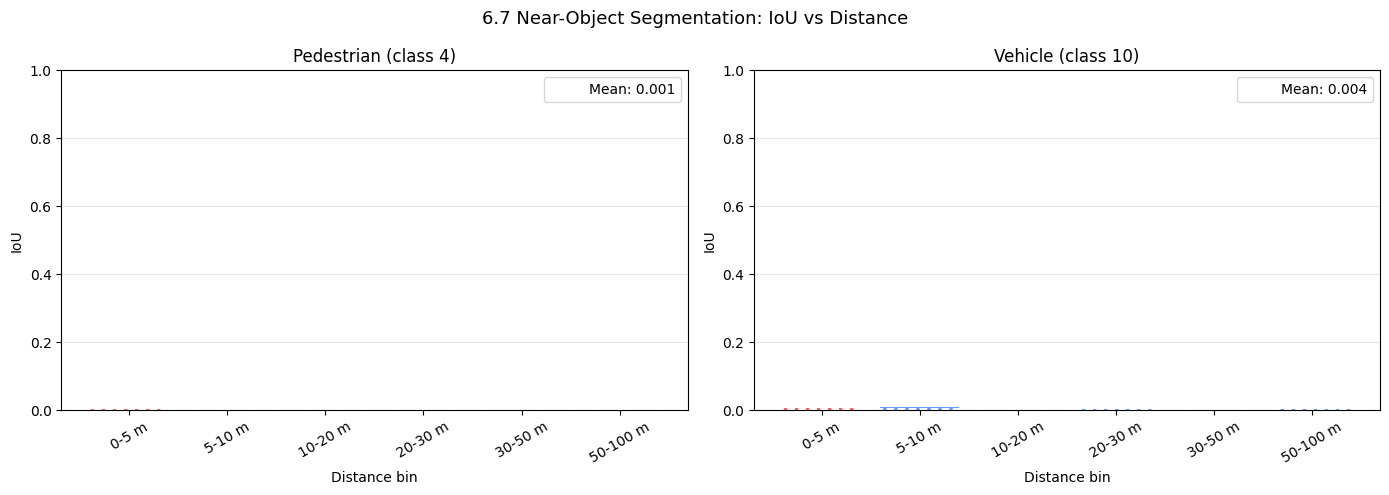

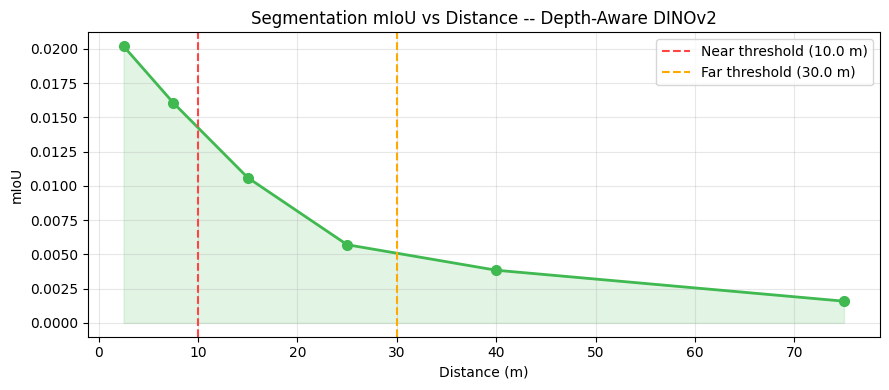


Near-Object IoU Summary
Class            Near (<10m)   Far (>30m)    Ratio
----------------------------------------------------
Pedestrian            0.0024       0.0006     4.31x
Vehicle               0.0084       0.0019     4.36x

COMPLETE SUMMARY
  Best model epoch       : 24
  Best model mIoU        : 0.5340
  Final test mIoU        : 0.5340
  Final test pixAcc      : 0.9403
  Distance bins evaluated: 6
  LiDAR points used      : 13,040,072
  All outputs in         : /kaggle/working/checkpoints_depth_aware


In [19]:
NEAR_CLASSES = {"Pedestrian": 4, "Vehicle": 10}  # CARLA class IDs

fig, axes = plt.subplots(1, len(NEAR_CLASSES), figsize=(14, 5))
fig.suptitle("6.7 Near-Object Segmentation: IoU vs Distance", fontsize=13)

for ax, (cls_name, cls_id) in zip(axes, NEAR_CLASSES.items()):
    if cls_id < K:
        iou_curve = per_cls[:, cls_id]
        ax.bar(bin_labels, iou_curve,
               color=["#ff4444" if i == 0 else "#4488ff" for i in range(n_bins)],
               alpha=0.85)
        ax.axhline(np.nanmean(iou_curve), color="white", ls="--",
                   lw=1.5, label=f"Mean: {np.nanmean(iou_curve):.3f}")
        ax.set_title(f"{cls_name} (class {cls_id})")
        ax.set_ylim(0, 1.0)
        ax.set_xlabel("Distance bin"); ax.set_ylabel("IoU")
        ax.tick_params(axis="x", rotation=30)
        ax.legend(); ax.grid(axis="y", alpha=0.3)
    else:
        ax.set_title(f"{cls_name} not in class space"); ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "near_object_iou.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# mIoU vs distance line plot
bin_centers = 0.5 * (np.array(cfg.distance_bins[:-1])
                      + np.array(cfg.distance_bins[1:]))

plt.figure(figsize=(9, 4))
plt.plot(bin_centers, miou_vals, "o-", color="#3fb950", lw=2, ms=7)
plt.fill_between(bin_centers, miou_vals, alpha=0.15, color="#3fb950")
plt.axvline(cfg.depth_near_thresh, color="#ff4444", ls="--", lw=1.5,
            label=f"Near threshold ({cfg.depth_near_thresh} m)")
plt.axvline(cfg.depth_far_thresh,  color="#ffaa00", ls="--", lw=1.5,
            label=f"Far threshold ({cfg.depth_far_thresh} m)")
plt.xlabel("Distance (m)"); plt.ylabel("mIoU")
plt.title("Segmentation mIoU vs Distance -- Depth-Aware DINOv2")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "miou_vs_distance.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# Near vs far summary
print("\nNear-Object IoU Summary")
print(f"{'Class':<15} {'Near (<10m)':>12} {'Far (>30m)':>12} {'Ratio':>8}")
print("-" * 52)
for cls_name, cls_id in NEAR_CLASSES.items():
    if cls_id < K:
        near_m = float(np.nanmean(per_cls[:2, cls_id]))  # first 2 bins
        far_m  = float(np.nanmean(per_cls[-2:, cls_id])) # last 2 bins
        ratio  = near_m / far_m if far_m > 0 else float("nan")
        print(f"{cls_name:<15} {near_m:>12.4f} {far_m:>12.4f} {ratio:>8.2f}x")

print("\n" + "="*60)
print("COMPLETE SUMMARY")
print("="*60)
print(f"  Best model epoch       : {best_epoch}")
print(f"  Best model mIoU        : {best_miou:.4f}")
print(f"  Final test mIoU        : {miou_f:.4f}")
print(f"  Final test pixAcc      : {pixacc_f:.4f}")
print(f"  Distance bins evaluated: {n_bins}")
print(f"  LiDAR points used      : {pt_counts.sum():,}")
print(f"  All outputs in         : {cfg.out_dir}")
print("="*60)


  safe_test_loader: 313 batches  (dataset size=625)
9.1  Overview of Vision Transformer Attention
  Backbone      : dinov2_vitb14
  Patch size    : 14px
  Embed dim     : 768
  Attention heads: 12
  d_k per head  : 64
  Grid @ 518×518: 37×37 = 1369 patch tokens

  ViT Attention Flow:
  ┌──────────────────────────────────────────────────────┐
  │  Input image  518×518×3                              │
  │      ↓  patch embed (14×14)                          │
  │  1369 spatial tokens + 1 [CLS]                       │
  │      ↓  12 transformer blocks                    │
  │  MHSA (12 heads, d_k=64)  ← we hook here (last block) │
  │      ↓  multi-layer fusion decoder                   │
  │  Segmentation logits  518×518×25              │
  └──────────────────────────────────────────────────────┘

9.2  Patch-Level Attention Visualisation


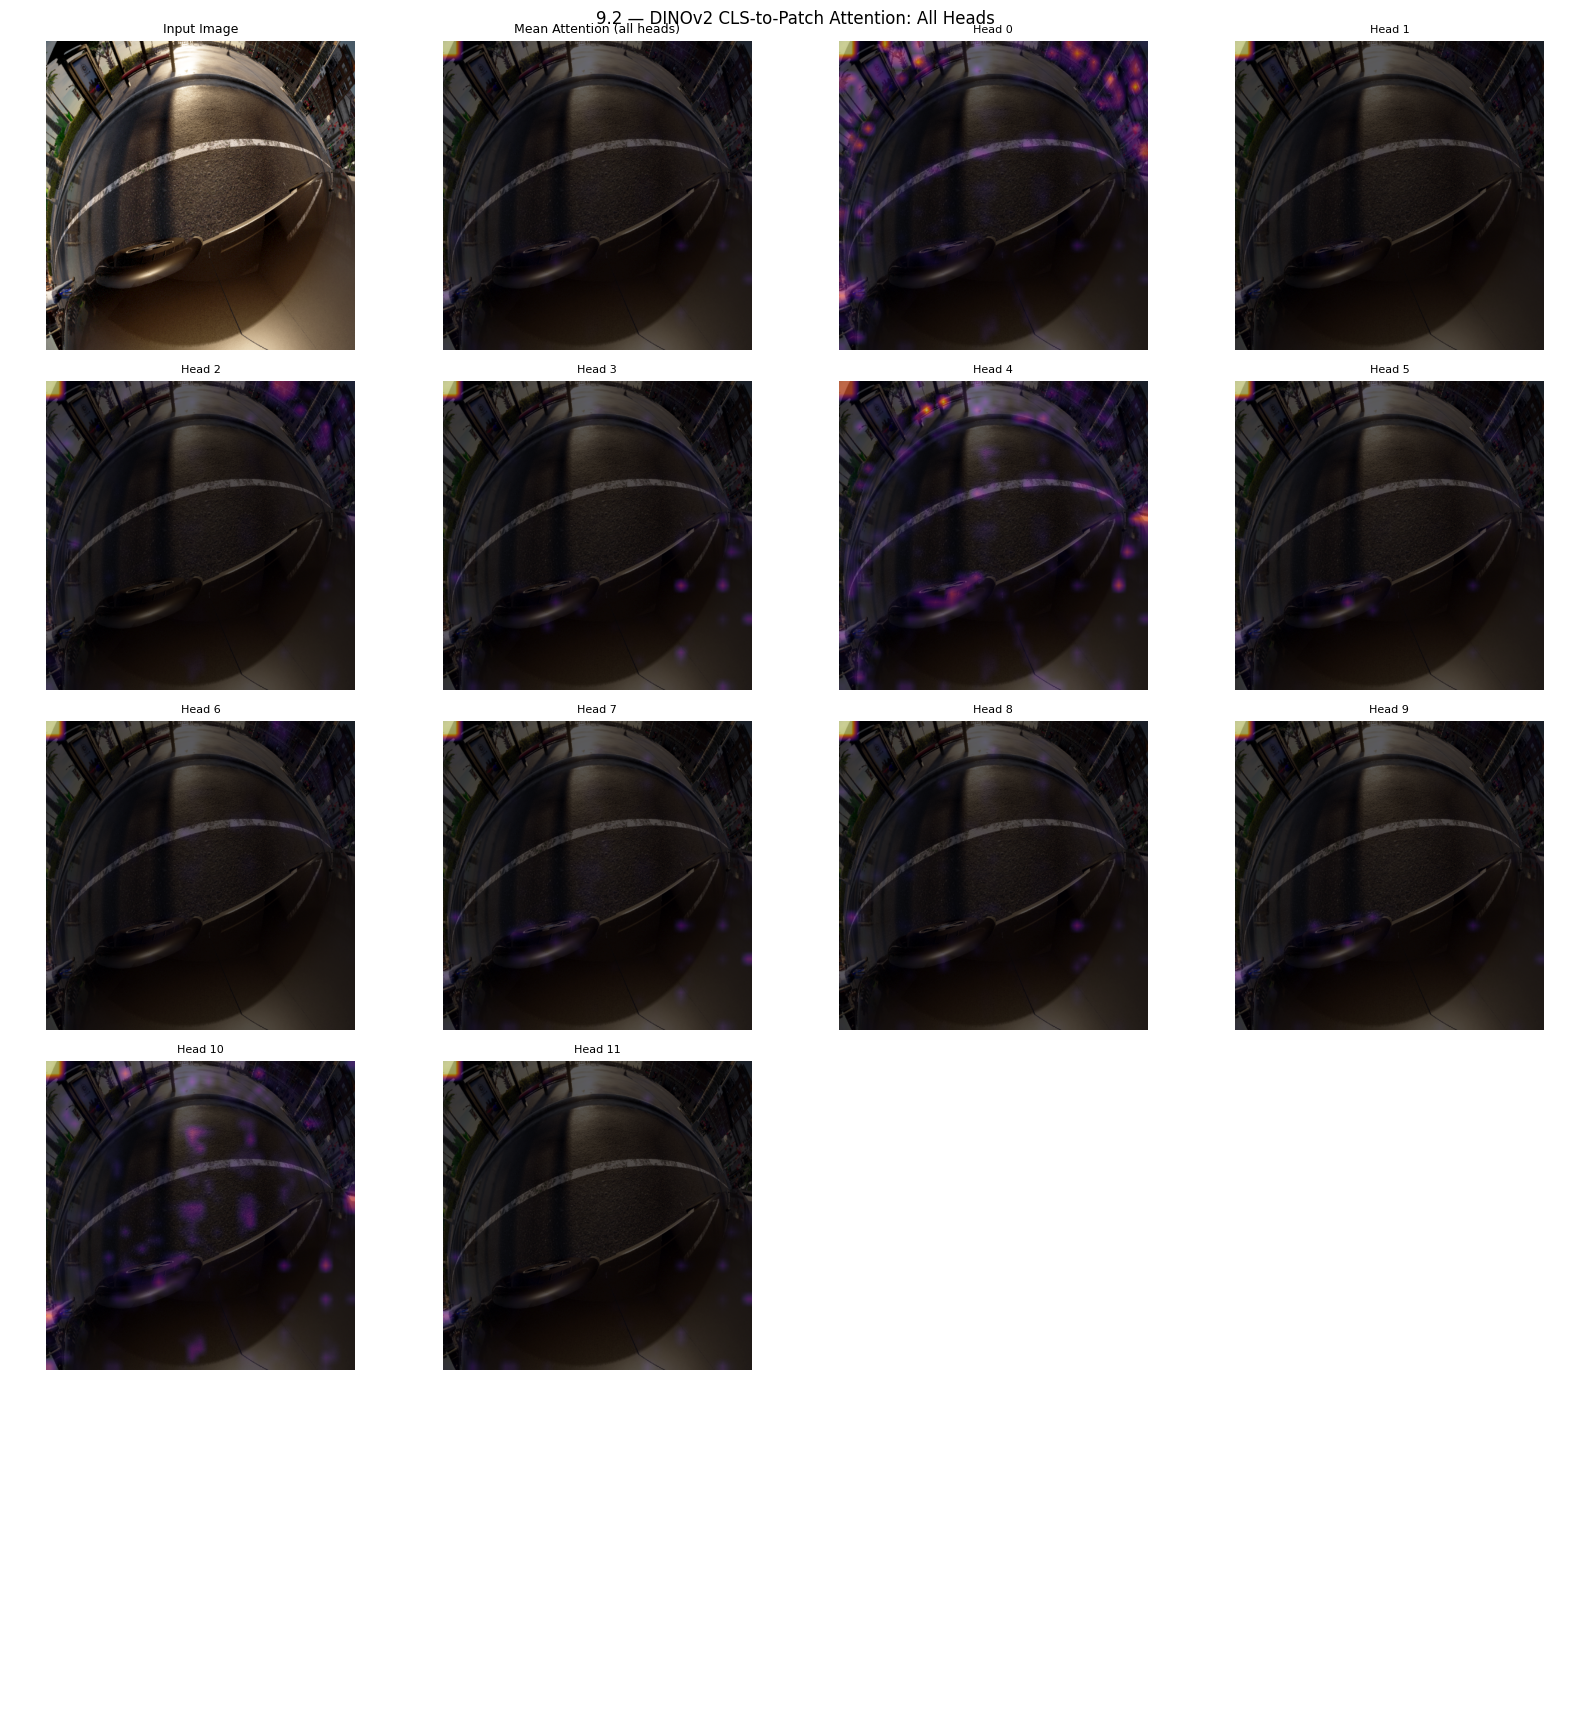

  Saved → 9_2_attention_all_heads.png


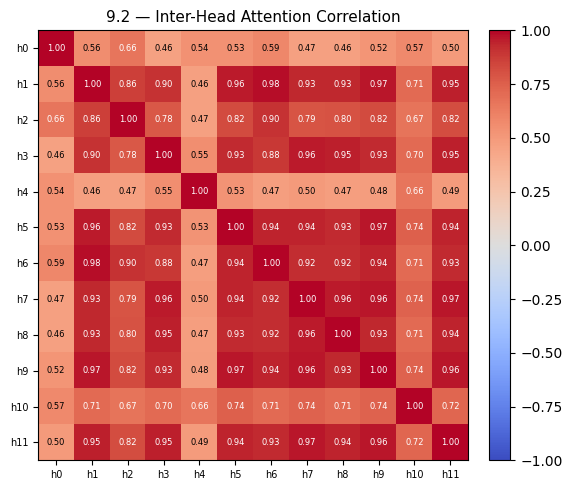

  Saved → 9_2_head_correlation.png
  Mean inter-head correlation: 0.7627
  (lower → heads are more diverse / complementary)

9.3  Attention Shift Across Domains


9.3 collecting attention:   0%|          | 0/313 [00:00<?, ?it/s]


  Samples collected per camera:
    FV: 30
    MVL: 30
    MVR: 30
    RV: 30

  Camera  Samples   Entropy    CoM-row    CoM-col  
  --------------------------------------------------
  FV            30     6.0819     11.738     13.907
  MVL           30     6.1355     10.436     14.922
  MVR           30     6.2020     11.639     13.342
  RV            30     6.1378      8.827     14.462


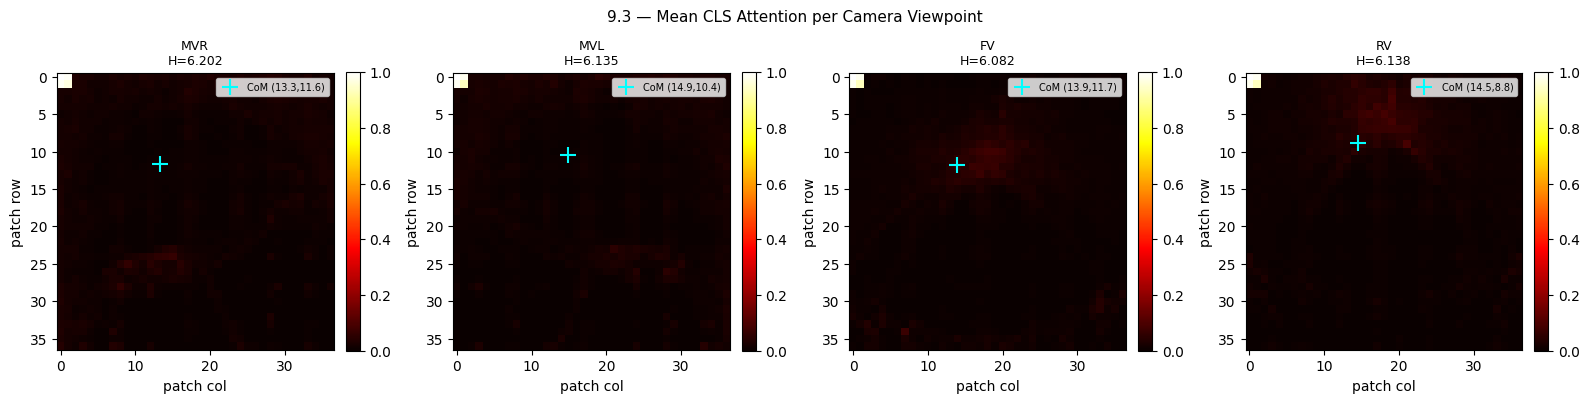

  Saved → 9_3_attention_per_camera.png


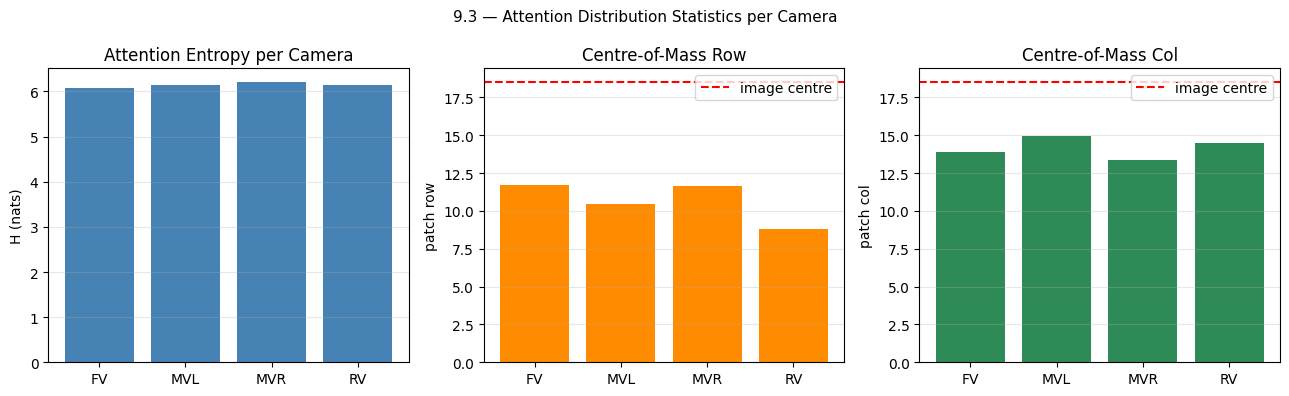

  Saved → 9_3_attention_stats_per_camera.png

9.4  Attention Collapse in Failure Cases


9.4 scanning collapse:   0%|          | 0/313 [00:00<?, ?it/s]


  Collapse score  —  min: 0.0346  max: 0.0727  mean: 0.0571
  Collapse threshold (p90): 0.0667
  Samples above threshold : 6 / 60


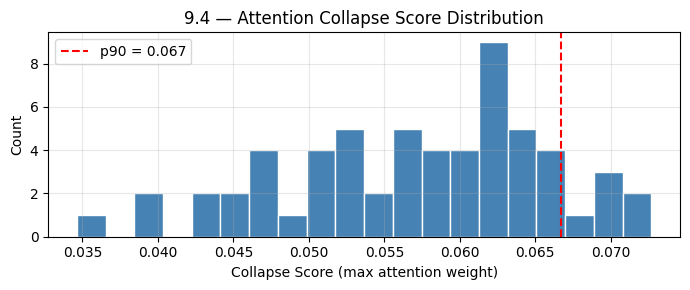

  Saved → 9_4_collapse_distribution.png


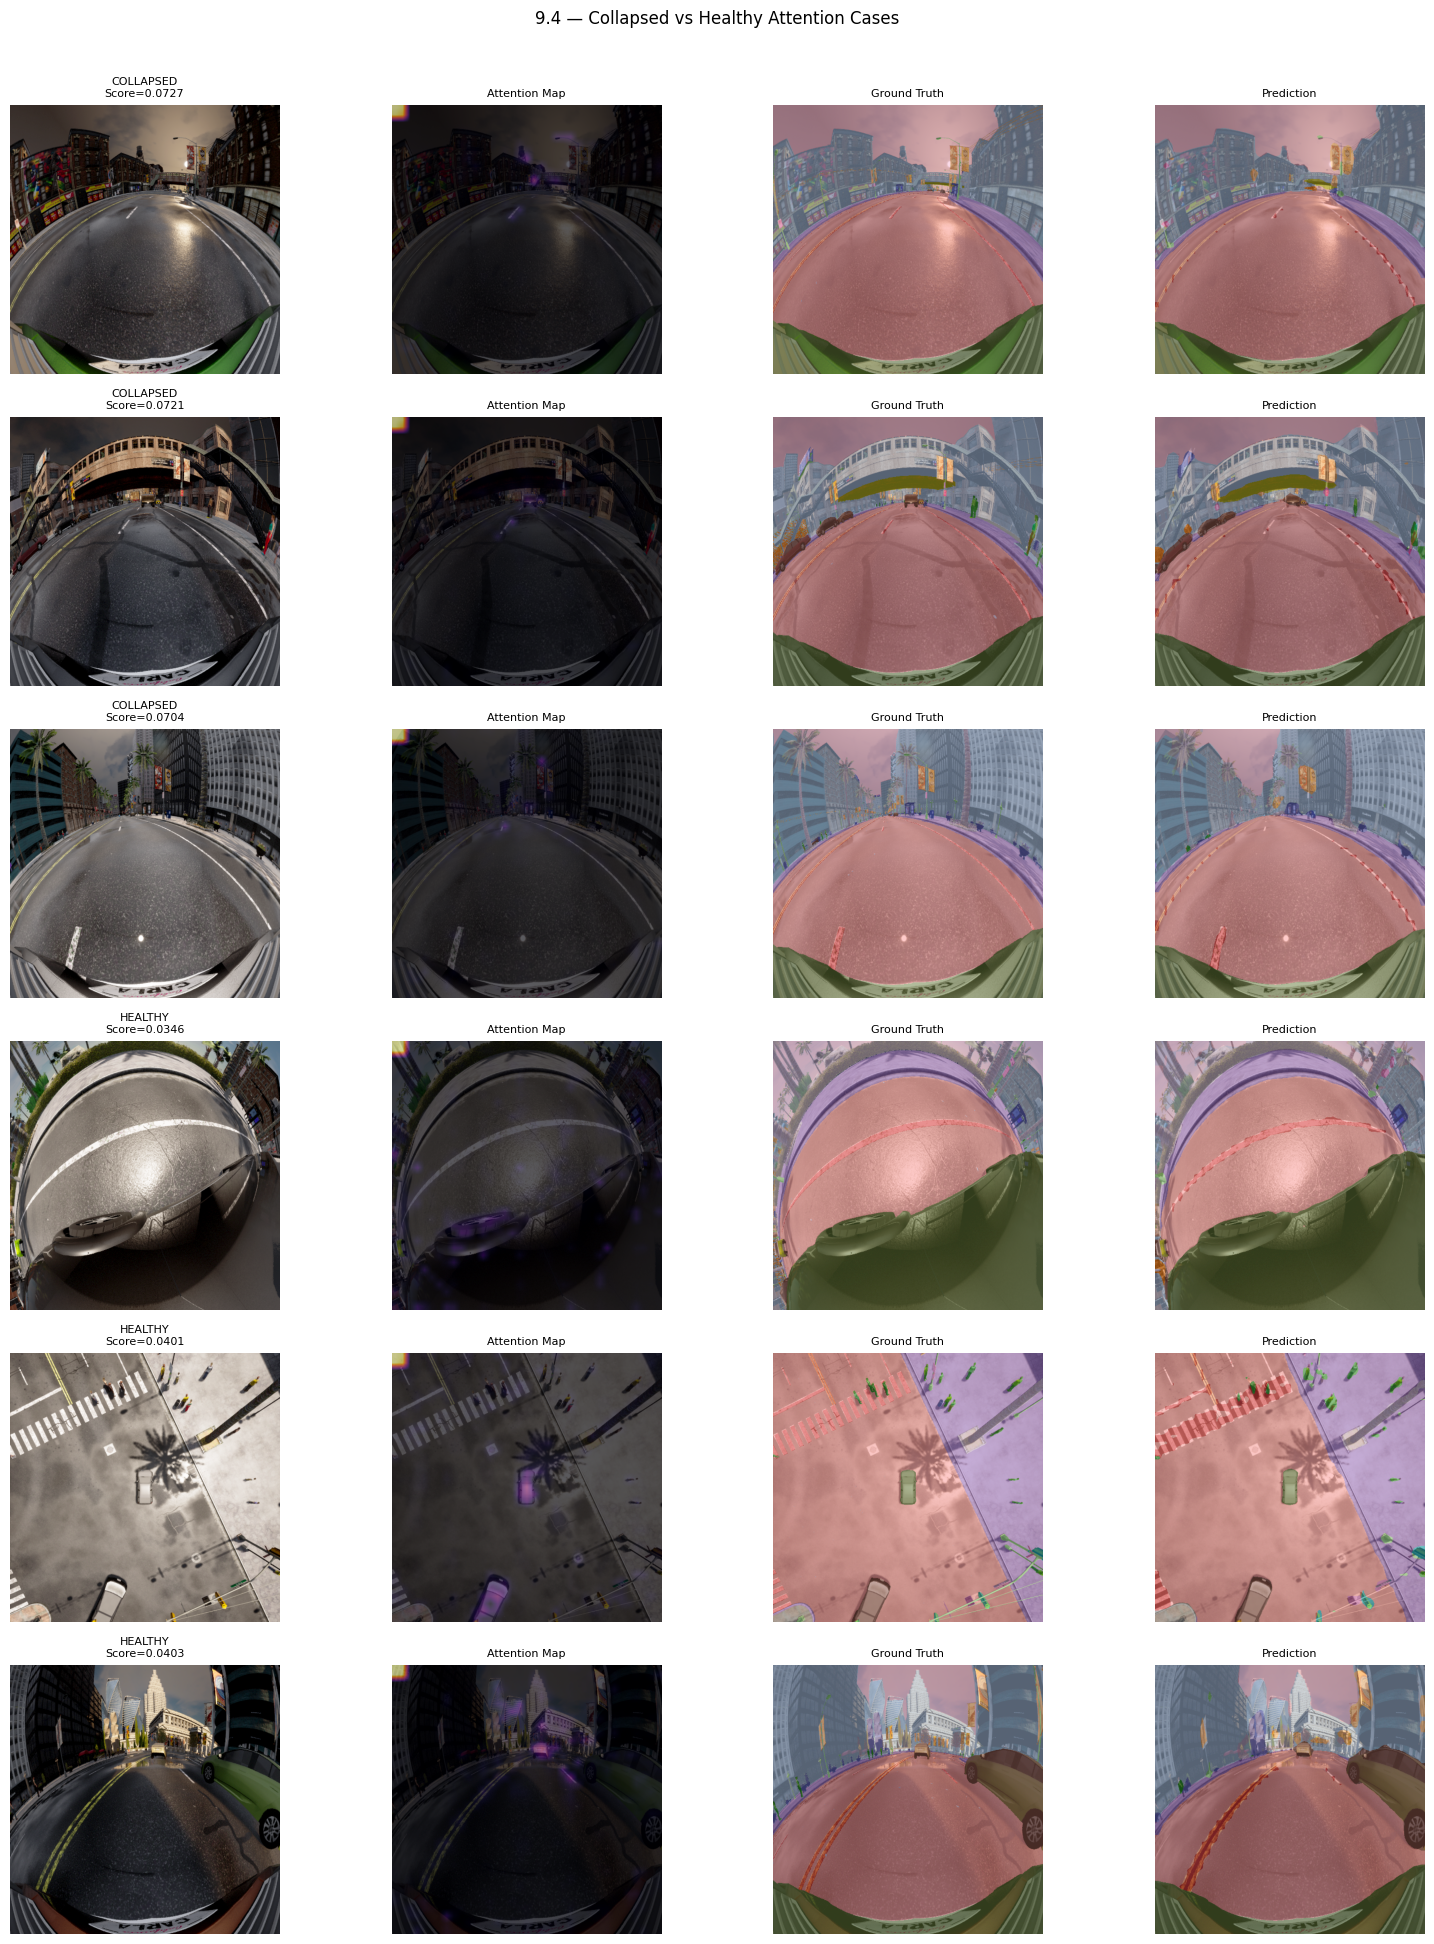

  Saved → 9_4_collapse_vs_healthy.png

  Mean mIoU — collapsed samples : 0.3889
  Mean mIoU — healthy   samples : 0.5208
  Δ mIoU                        : +0.1319

9.5  Correlating Attention Patterns with Depth


9.5 depth-attention correlation:   0%|          | 0/50 [00:00<?, ?it/s]


  Mean attention weight per depth bin:
  near (<10m)       : 0.00671  (n=50)
  mid (10-30m)      : 0.01126  (n=50)
  far (>30m)        : 0.03492  (n=50)


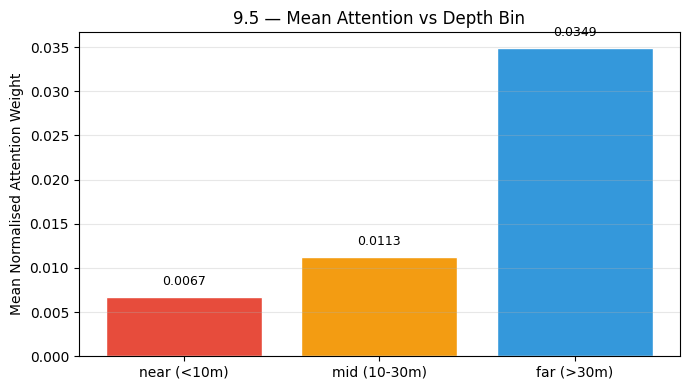

  Saved → 9_5_attention_vs_depth_bin.png


/tmp/ipykernel_7340/3697182607.py:667: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(depths_sc[valid_fit], entropies_sc[valid_fit], 1)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


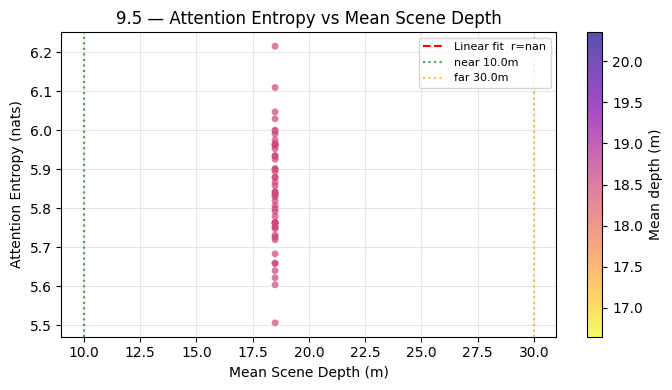

  Saved → 9_5_entropy_vs_depth.png
  Pearson r (depth vs entropy): nan


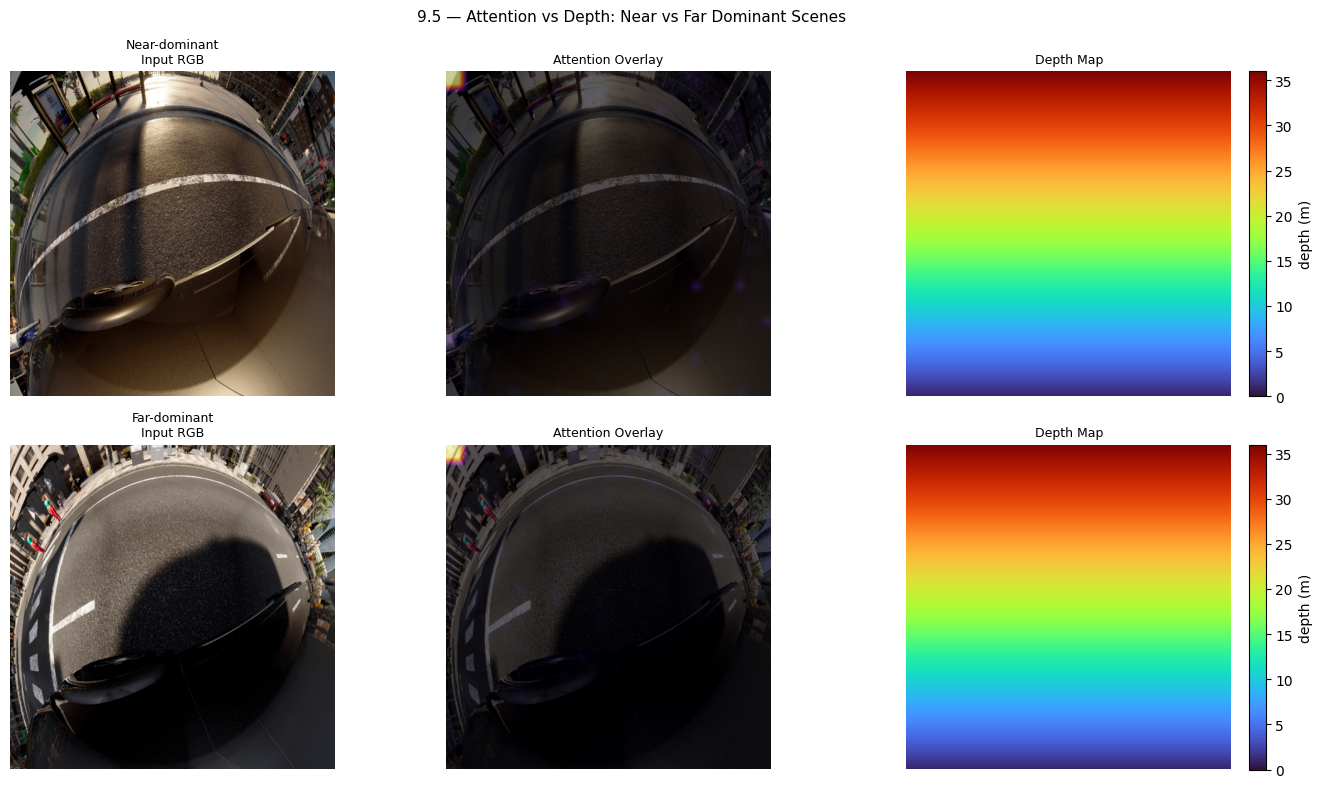

  Saved → 9_5_near_vs_far_qualitative.png

SECTION 9 — ATTENTION ANALYSIS SUMMARY

  9.1  Architecture: dinov2_vitb14  |  12 heads  |  patch=14px  |  grid=37×37

  9.2  Head diversity (mean inter-head corr): 0.7627
       Heads show high redundancy

  9.3  Entropy range across cameras: 6.082 – 6.202
       Most diffuse: MVR  |  Most focused: FV

  9.4  Collapse threshold (p90): 0.0667
       Collapsed mIoU=0.3889  Healthy mIoU=0.5208
       Attention collapse → Δ mIoU = +0.1319

  9.5  Depth-attention correlation:
       near (<10m)       : mean_attn = 0.00671
       mid (10-30m)      : mean_attn = 0.01126
       far (>30m)        : mean_attn = 0.03492

  Figures saved to: /kaggle/working/checkpoints_depth_aware/attention_analysis
    9_2_attention_all_heads.png
    9_2_head_correlation.png
    9_3_attention_per_camera.png
    9_3_attention_stats_per_camera.png
    9_4_collapse_distribution.png
    9_4_collapse_vs_healthy.png
    9_5_attention_vs_depth_bin.png
    9_5_entropy_vs_depth.

In [20]:
# ==============================================================================
# SECTION 9: ATTENTION AND TRANSFORMER BEHAVIOR ANALYSIS
# DINOv2 Fisheye Semantic Segmentation — SynWoodScape Depth-Aware Pipeline
# ==============================================================================
# Requires: model, cfg, DEVICE, test_loader, CARLA_CLASS_NAMES, palette
#           built_palette(), colourise(), IMAGENET_MEAN, IMAGENET_STD
# ==============================================================================

import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from tqdm.auto import tqdm
from collections import defaultdict

# ── shared output directory ────────────────────────────────────────────────────
ATTN_OUT = os.path.join(cfg.out_dir, "attention_analysis")
os.makedirs(ATTN_OUT, exist_ok=True)

# ── Safe loader for attention analysis (num_workers=0 avoids worker crashes) ──
# The original test_loader may use multiple workers which can crash inside a
# notebook when the forked process tries to re-initialise CUDA or the model.
# We rebuild it here with num_workers=0 and a small batch size.
from torch.utils.data import DataLoader as _DL
_attn_ds = test_loader.dataset          # reuse the same dataset object
safe_test_loader = _DL(
    _attn_ds,
    batch_size  = 2,
    shuffle     = False,
    num_workers = 0,                    # ← key fix: no forked workers
    pin_memory  = False,
)
print(f"  safe_test_loader: {len(safe_test_loader)} batches  "
      f"(dataset size={len(_attn_ds)})")

# ==============================================================================
# 9.1  OVERVIEW OF VISION TRANSFORMER ATTENTION
# ==============================================================================
# DINOv2 is a Vision Transformer (ViT) trained with self-supervised DINO-v2
# distillation.  The backbone splits every input frame into non-overlapping
# 14×14-pixel patches and projects them to token embeddings.  A prepended [CLS]
# token aggregates global context; the remaining N = (H/14)×(W/14) tokens carry
# spatial information.
#
# Each transformer block contains a multi-head self-attention (MHSA) layer.
# For a query token i and key token j the raw attention score is:
#
#        a_{ij} = softmax( (Q_i · K_j) / sqrt(d_k) )
#
# where d_k = embed_dim / num_heads.  The final attended representation is
# V weighted by a_{ij} summed over all j.
#
# We hook into the *last* transformer block to capture the attention maps that
# immediately precede the decoder. For an image of size 518×518 with patch
# size 14 the spatial grid is 37×37 = 1 369 patch tokens.
# ==============================================================================

print("=" * 60)
print("9.1  Overview of Vision Transformer Attention")
print("=" * 60)

# ── Patch / head metadata ─────────────────────────────────────────────────────
PATCH_SIZE  = model.patch_size                        # 14
EMBED_DIM   = model.embed_dim                         # 768
NUM_HEADS   = model.backbone.blocks[-1].attn.num_heads
D_K         = EMBED_DIM // NUM_HEADS
H_IMG, W_IMG = cfg.target_size                        # 518, 518
H_PATCH     = H_IMG // PATCH_SIZE                     # 37
W_PATCH     = W_IMG // PATCH_SIZE                     # 37
N_PATCHES   = H_PATCH * W_PATCH                       # 1 369

print(f"  Backbone      : {cfg.model_name}")
print(f"  Patch size    : {PATCH_SIZE}px")
print(f"  Embed dim     : {EMBED_DIM}")
print(f"  Attention heads: {NUM_HEADS}")
print(f"  d_k per head  : {D_K}")
print(f"  Grid @ {H_IMG}×{W_IMG}: {H_PATCH}×{W_PATCH} = {N_PATCHES} patch tokens")

# ── Architecture summary diagram (text) ───────────────────────────────────────
print("\n  ViT Attention Flow:")
print("  ┌──────────────────────────────────────────────────────┐")
print(f"  │  Input image  {H_IMG}×{W_IMG}×3                              │")
print(f"  │      ↓  patch embed (14×14)                          │")
print(f"  │  {N_PATCHES} spatial tokens + 1 [CLS]                       │")
print(f"  │      ↓  {len(model.backbone.blocks)} transformer blocks                    │")
print(f"  │  MHSA ({NUM_HEADS} heads, d_k={D_K})  ← we hook here (last block) │")
print(f"  │      ↓  multi-layer fusion decoder                   │")
print(f"  │  Segmentation logits  {H_IMG}×{W_IMG}×{cfg.num_classes}              │")
print("  └──────────────────────────────────────────────────────┘")


# ==============================================================================
# 9.2  PATCH-LEVEL ATTENTION VISUALISATION
# ==============================================================================
# We register a forward hook on the last transformer block's MHSA module.
# The hook captures the full attention weight matrix (B, H, N+1, N+1).
# We extract the [CLS]→patch slice (row 0, columns 1:) to obtain a global
# "saliency" map and also inspect individual head maps.
# ==============================================================================

print("\n" + "=" * 60)
print("9.2  Patch-Level Attention Visualisation")
print("=" * 60)

_attn_store: dict = {}

def _attn_hook(module, input, output):
    """Store the attention weight tensor produced by the last MHSA block."""
    # DINOv2 Attention.forward() returns (x,) but we need the weights.
    # We re-run the QKV projection in no-grad mode to obtain attn_weights.
    with torch.no_grad():
        B, N, C = input[0].shape
        qkv = module.qkv(input[0])                          # (B, N, 3*C)
        qkv = qkv.reshape(B, N, 3, module.num_heads, C // module.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)                   # (3, B, H, N, d)
        q, k, _ = qkv.unbind(0)
        scale   = (C // module.num_heads) ** -0.5
        attn    = (q @ k.transpose(-2, -1)) * scale         # (B, H, N, N)
        attn    = attn.softmax(dim=-1)
        _attn_store["weights"] = attn.detach().cpu()         # (B, H, N+1, N+1)

hook_handle = model.backbone.blocks[-1].attn.register_forward_hook(_attn_hook)


def get_attention_maps(img_tensor: torch.Tensor) -> torch.Tensor:
    """
    Run one forward pass and return attention maps.

    Parameters
    ----------
    img_tensor : (1, 3, H, W) normalised tensor on DEVICE

    Returns
    -------
    attn : (num_heads, H_patch, W_patch)  CLS-to-patch attention per head
    """
    model.eval()
    with torch.no_grad():
        _ = model(img_tensor)
    attn_raw = _attn_store["weights"]          # (1, H, N+1, N+1)
    cls_attn = attn_raw[0, :, 0, 1:]           # (H, N_patches)
    cls_attn = cls_attn.reshape(NUM_HEADS, H_PATCH, W_PATCH)
    return cls_attn                             # (H, H_patch, W_patch)


def upscale_attn(attn_hw: torch.Tensor) -> np.ndarray:
    """Bilinearly upscale a (H_patch, W_patch) map to (H_img, W_img)."""
    t = attn_hw.unsqueeze(0).unsqueeze(0).float()          # (1,1,h,w)
    up = F.interpolate(t, size=(H_IMG, W_IMG),
                       mode="bilinear", align_corners=False)
    arr = up.squeeze().numpy()
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)


# ── Fetch one sample from the test loader ─────────────────────────────────────
sample_batch  = next(iter(safe_test_loader))
sample_img_t  = sample_batch["image"][0:1].to(DEVICE)      # (1,3,H,W)
sample_img_np = sample_batch["image"][0].permute(1,2,0).numpy()
sample_img_np = (sample_img_np * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)

attn_heads = get_attention_maps(sample_img_t)              # (H, 37, 37)

# ── Plot: all heads + mean head ───────────────────────────────────────────────
mean_attn    = attn_heads.mean(0)                          # (37, 37)
mean_attn_up = upscale_attn(mean_attn)

n_cols  = 4
n_rows  = (NUM_HEADS // n_cols) + 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

axes[0].imshow(sample_img_np)
axes[0].set_title("Input Image", fontsize=9); axes[0].axis("off")

axes[1].imshow(sample_img_np)
axes[1].imshow(mean_attn_up, alpha=0.6, cmap="inferno")
axes[1].set_title("Mean Attention (all heads)", fontsize=9); axes[1].axis("off")

for h in range(NUM_HEADS):
    ax  = axes[h + 2]
    up  = upscale_attn(attn_heads[h])
    ax.imshow(sample_img_np)
    im  = ax.imshow(up, alpha=0.65, cmap="inferno")
    ax.set_title(f"Head {h}", fontsize=8); ax.axis("off")

for ax in axes[NUM_HEADS + 2:]:
    ax.axis("off")

plt.suptitle("9.2 — DINOv2 CLS-to-Patch Attention: All Heads", fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(ATTN_OUT, "9_2_attention_all_heads.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → 9_2_attention_all_heads.png")


# ── Head-diversity stats ───────────────────────────────────────────────────────
head_corr = np.corrcoef(
    attn_heads.reshape(NUM_HEADS, -1).numpy()
)   # (H, H)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(head_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(NUM_HEADS)); ax.set_yticks(range(NUM_HEADS))
ax.set_xticklabels([f"h{i}" for i in range(NUM_HEADS)], fontsize=7)
ax.set_yticklabels([f"h{i}" for i in range(NUM_HEADS)], fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for r in range(NUM_HEADS):
    for c in range(NUM_HEADS):
        ax.text(c, r, f"{head_corr[r,c]:.2f}", ha="center",
                va="center", fontsize=6,
                color="white" if abs(head_corr[r,c]) > 0.6 else "black")
ax.set_title("9.2 — Inter-Head Attention Correlation", fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(ATTN_OUT, "9_2_head_correlation.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → 9_2_head_correlation.png")

mean_off_diag = (head_corr.sum() - np.trace(head_corr)) / (NUM_HEADS * (NUM_HEADS - 1))
print(f"  Mean inter-head correlation: {mean_off_diag:.4f}")
print(f"  (lower → heads are more diverse / complementary)")


# ==============================================================================
# 9.3  ATTENTION SHIFT ACROSS DOMAINS
# ==============================================================================
# SynWoodScape contains four fisheye cameras (FV, MVL, MVR, RV).  Each camera
# viewpoint creates a distinct distortion pattern that may shift where the
# model focuses.  We collect mean attention maps per camera name and compare
# their spatial distributions with: centre-of-mass shift, entropy, and
# peak-location consistency.
# ==============================================================================

print("\n" + "=" * 60)
print("9.3  Attention Shift Across Domains")
print("=" * 60)

CAMERAS        = cfg.camera_names                          # ["FV","MVL","MVR","RV"]
cam_attn_accum = defaultdict(list)                         # cam → [mean_attn_np, ...]

N_ATTN_SAMPLES = 30    # samples per camera (adjust to available data)

def cam_from_path(img_path: str) -> str:
    """
    Infer camera name from filename.
    SynWoodScape files are named like: 00001_FV.png / 00023_MVL.png
    Scans the stem for any known camera token (longer tokens first).
    """
    stem = os.path.splitext(os.path.basename(str(img_path)))[0].upper()
    for cam in ["MVL", "MVR", "FV", "RV"]:
        if cam in stem:
            return cam
    return "UNKNOWN"

model.eval()
sample_count   = defaultdict(int)
target_per_cam = N_ATTN_SAMPLES

for batch in tqdm(safe_test_loader, desc="9.3 collecting attention"):
    imgs      = batch["image"]
    img_paths = batch.get("img_path", [""] * imgs.size(0))

    for b in range(imgs.size(0)):
        cam = cam_from_path(img_paths[b])
        if cam not in CAMERAS:
            continue                           # skip unrecognised filenames
        if sample_count[cam] >= target_per_cam:
            continue

        x = imgs[b:b+1].to(DEVICE)
        a = get_attention_maps(x).mean(0)      # (37, 37)
        cam_attn_accum[cam].append(a.numpy())
        sample_count[cam] += 1

    if all(sample_count[c] >= target_per_cam for c in CAMERAS):
        break

# Report how many samples were collected per camera
print("\n  Samples collected per camera:")
for cam in CAMERAS:
    print(f"    {cam}: {sample_count[cam]}")

# ── Aggregate: mean attention map per camera ──────────────────────────────────
cam_mean_attn = {}
for cam, maps in cam_attn_accum.items():
    arr = np.stack(maps, 0).mean(0)                        # (37, 37)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    cam_mean_attn[cam] = arr

def attn_entropy(a: np.ndarray) -> float:
    """Shannon entropy of a normalised attention distribution."""
    p   = a.flatten() + 1e-10
    p  /= p.sum()
    return float(-np.sum(p * np.log(p)))

def centre_of_mass(a: np.ndarray):
    """(row, col) centre-of-mass in patch coordinates."""
    h, w    = a.shape
    rows    = np.arange(h); cols = np.arange(w)
    total   = a.sum() + 1e-10
    r_com   = (a.sum(axis=1) * rows).sum() / total
    c_com   = (a.sum(axis=0) * cols).sum() / total
    return float(r_com), float(c_com)

print(f"\n  {'Camera':6s}  {'Samples':8s}  {'Entropy':9s}  {'CoM-row':9s}  {'CoM-col':9s}")
print("  " + "-" * 50)
cam_stats = {}
for cam in CAMERAS:
    if cam not in cam_mean_attn:
        print(f"  {cam:6s}  no data")
        continue
    a   = cam_mean_attn[cam]
    ent = attn_entropy(a)
    r, c = centre_of_mass(a)
    cam_stats[cam] = {"entropy": ent, "com_row": r, "com_col": c}
    print(f"  {cam:6s}  {sample_count[cam]:8d}  {ent:9.4f}  {r:9.3f}  {c:9.3f}")

# ── Plot: mean attention maps per camera ──────────────────────────────────────
# Only plot cameras that have both attention data AND stats
cams_to_plot = [c for c in cam_mean_attn if c in cam_stats]

if not cams_to_plot:
    print("  WARNING: No camera attention data collected. Check that img_path "
          "filenames contain a camera token (FV, MVL, MVR, RV).")
    # Print a sample filename to help debug
    sample_path = str(safe_test_loader.dataset.pairs[0][0])
    print(f"  Sample filename: {os.path.basename(sample_path)}")
else:
    n_cams = len(cams_to_plot)
    fig, axes = plt.subplots(1, n_cams, figsize=(4 * n_cams, 4))
    if n_cams == 1: axes = [axes]

    for ax, cam in zip(axes, cams_to_plot):
        im = ax.imshow(cam_mean_attn[cam], cmap="hot", vmin=0, vmax=1)
        ent = cam_stats[cam]["entropy"]
        r, c = cam_stats[cam]["com_row"], cam_stats[cam]["com_col"]
        ax.scatter([c], [r], marker="+", s=120, c="cyan", linewidths=1.5,
                   label=f"CoM ({c:.1f},{r:.1f})")
        ax.set_title(f"{cam}\nH={ent:.3f}", fontsize=9)
        ax.set_xlabel("patch col"); ax.set_ylabel("patch row")
        ax.legend(fontsize=7, loc="upper right")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle("9.3 — Mean CLS Attention per Camera Viewpoint", fontsize=11)
    plt.tight_layout()
    fig.savefig(os.path.join(ATTN_OUT, "9_3_attention_per_camera.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → 9_3_attention_per_camera.png")

# ── Plot: entropy + CoM bar charts ────────────────────────────────────────────
if len(cam_stats) > 1:
    cams_sorted = sorted(cam_stats.keys())
    entropies   = [cam_stats[c]["entropy"]  for c in cams_sorted]
    com_rows    = [cam_stats[c]["com_row"]  for c in cams_sorted]
    com_cols    = [cam_stats[c]["com_col"]  for c in cams_sorted]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].bar(cams_sorted, entropies, color="steelblue")
    axes[0].set_title("Attention Entropy per Camera"); axes[0].set_ylabel("H (nats)")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(cams_sorted, com_rows, color="darkorange")
    axes[1].set_title("Centre-of-Mass Row"); axes[1].set_ylabel("patch row")
    axes[1].axhline(H_PATCH / 2, ls="--", c="red", label="image centre")
    axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

    axes[2].bar(cams_sorted, com_cols, color="seagreen")
    axes[2].set_title("Centre-of-Mass Col"); axes[2].set_ylabel("patch col")
    axes[2].axhline(W_PATCH / 2, ls="--", c="red", label="image centre")
    axes[2].legend(); axes[2].grid(axis="y", alpha=0.3)

    plt.suptitle("9.3 — Attention Distribution Statistics per Camera", fontsize=11)
    plt.tight_layout()
    fig.savefig(os.path.join(ATTN_OUT, "9_3_attention_stats_per_camera.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → 9_3_attention_stats_per_camera.png")


# ==============================================================================
# 9.4  ATTENTION COLLAPSE IN FAILURE CASES
# ==============================================================================
# "Attention collapse" occurs when nearly all attention mass concentrates on
# a single token (typically [CLS] itself or one dominant background patch),
# causing the model to ignore spatial detail and produce degraded predictions.
# We define a collapse score as the maximum single-token attention weight
# (after softmax).  High values → collapsed; low values → well-distributed.
# We surface samples with the highest collapse scores and examine their
# predictions alongside a correctly-attending baseline.
# ==============================================================================

print("\n" + "=" * 60)
print("9.4  Attention Collapse in Failure Cases")
print("=" * 60)


def collapse_score(attn_heads_hw: torch.Tensor) -> float:
    """
    Returns the mean-head maximum patch-attention weight.

    attn_heads_hw : (num_heads, H_patch, W_patch)
    """
    flat = attn_heads_hw.reshape(NUM_HEADS, -1)    # (H, N)
    return float(flat.max(dim=-1).values.mean())


N_COLLAPSE_SAMPLES = 60    # total samples to scan

collapse_records = []      # list of {score, img_np, pred_np, gt_np, attn_up}

model.eval()
scanned = 0

for batch in tqdm(safe_test_loader, desc="9.4 scanning collapse"):
    imgs = batch["image"]
    msks = batch["mask"]

    for b in range(imgs.size(0)):
        if scanned >= N_COLLAPSE_SAMPLES:
            break

        x     = imgs[b:b+1].to(DEVICE)
        a_h   = get_attention_maps(x)                     # (H, 37, 37)
        score = collapse_score(a_h)

        img_np = imgs[b].permute(1, 2, 0).numpy()
        img_np = (img_np * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)

        with torch.no_grad():
            pred_np = model(x).argmax(dim=1).squeeze(0).cpu().numpy()

        gt_np     = msks[b].numpy()
        attn_up   = upscale_attn(a_h.mean(0))

        collapse_records.append({
            "score":   score,
            "img_np":  img_np,
            "pred_np": pred_np,
            "gt_np":   gt_np,
            "attn_up": attn_up,
        })
        scanned += 1

    if scanned >= N_COLLAPSE_SAMPLES:
        break

collapse_records.sort(key=lambda r: r["score"], reverse=True)

scores_all = [r["score"] for r in collapse_records]
print(f"\n  Collapse score  —  min: {min(scores_all):.4f}  "
      f"max: {max(scores_all):.4f}  "
      f"mean: {np.mean(scores_all):.4f}")

# ── Threshold: top-10 % as "collapsed" ────────────────────────────────────────
threshold  = np.percentile(scores_all, 90)
n_collapse = sum(s >= threshold for s in scores_all)
print(f"  Collapse threshold (p90): {threshold:.4f}")
print(f"  Samples above threshold : {n_collapse} / {scanned}")

# ── Score distribution ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(scores_all, bins=20, color="steelblue", edgecolor="white")
ax.axvline(threshold, color="red", ls="--", lw=1.5,
           label=f"p90 = {threshold:.3f}")
ax.set_xlabel("Collapse Score (max attention weight)"); ax.set_ylabel("Count")
ax.set_title("9.4 — Attention Collapse Score Distribution")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(ATTN_OUT, "9_4_collapse_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → 9_4_collapse_distribution.png")

# ── Qualitative: worst (collapsed) vs best (healthy) ─────────────────────────
def _blend_pred(img_np, pred_np, pal):
    col = colourise(pred_np.astype(np.int32), pal)
    return np.clip(img_np * 0.5 + col * 0.5, 0, 1)

N_SHOW = 3
worst  = collapse_records[:N_SHOW]
best   = collapse_records[-N_SHOW:][::-1]

fig, axes = plt.subplots(N_SHOW * 2, 4,
                         figsize=(16, N_SHOW * 2 * 3.2))
row_labels = (["COLLAPSED"] * N_SHOW) + (["HEALTHY"] * N_SHOW)

for row_idx, rec in enumerate(worst + best):
    pal   = build_palette(cfg.num_classes)
    blend = _blend_pred(rec["img_np"], rec["pred_np"], pal)
    gt_b  = _blend_pred(rec["img_np"], rec["gt_np"],   pal)

    axes[row_idx, 0].imshow(rec["img_np"])
    axes[row_idx, 0].set_title(
        f"{row_labels[row_idx]}\nScore={rec['score']:.4f}", fontsize=8)
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(rec["img_np"])
    axes[row_idx, 1].imshow(rec["attn_up"], alpha=0.65, cmap="inferno")
    axes[row_idx, 1].set_title("Attention Map", fontsize=8)
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(gt_b)
    axes[row_idx, 2].set_title("Ground Truth", fontsize=8)
    axes[row_idx, 2].axis("off")

    axes[row_idx, 3].imshow(blend)
    axes[row_idx, 3].set_title("Prediction", fontsize=8)
    axes[row_idx, 3].axis("off")

plt.suptitle("9.4 — Collapsed vs Healthy Attention Cases",
             fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(ATTN_OUT, "9_4_collapse_vs_healthy.png"),
            dpi=130, bbox_inches="tight")
plt.show()
print(f"  Saved → 9_4_collapse_vs_healthy.png")

# ── mIoU comparison: collapsed vs healthy ─────────────────────────────────────
def sample_miou(rec):
    gt   = rec["gt_np"].astype(np.int32)
    pred = rec["pred_np"].astype(np.int32)
    ious = []
    for c in range(cfg.num_classes):
        tp = int(((gt == c) & (pred == c)).sum())
        fp = int(((gt != c) & (pred == c)).sum())
        fn = int(((gt == c) & (pred != c)).sum())
        d  = tp + fp + fn
        if d > 0:
            ious.append(tp / d)
    return float(np.mean(ious)) if ious else 0.0

collapsed_miou = np.mean([sample_miou(r) for r in worst])
healthy_miou   = np.mean([sample_miou(r) for r in best])
print(f"\n  Mean mIoU — collapsed samples : {collapsed_miou:.4f}")
print(f"  Mean mIoU — healthy   samples : {healthy_miou:.4f}")
print(f"  Δ mIoU                        : {healthy_miou - collapsed_miou:+.4f}")


# ==============================================================================
# 9.5  CORRELATING ATTENTION PATTERNS WITH DEPTH
# ==============================================================================
# Depth information (from the LiDAR projection pipeline in §6.2-6.3) provides
# a per-pixel distance signal.  We test two hypotheses:
#
#   H1: Attention is higher in near-range regions (distance < near_thresh).
#   H2: Attention entropy is lower for far-range dominant patches (model is
#       more uncertain about background and distributes attention evenly).
#
# We use the pre-computed sparse depth maps (stored as .npy alongside RGB)
# and bin them into the same distance bands as cfg.distance_bins.
# ==============================================================================

print("\n" + "=" * 60)
print("9.5  Correlating Attention Patterns with Depth")
print("=" * 60)

# ── Helper: load depth map for a sample ───────────────────────────────────────
def load_depth_for_sample(img_path: str) -> np.ndarray:
    """
    Return a (H_img, W_img) depth array (metres, 0 = invalid).
    Looks for a .npy depth file adjacent to the RGB image.
    Falls back to a synthetic gradient if not found.
    """
    img_path_str = str(img_path)
    depth_path = img_path_str.replace("/rgb_images/", "/depth_maps/") \
                              .replace(".jpg", ".npy").replace(".png", ".npy")
    if os.path.exists(depth_path):
        d = np.load(depth_path)
        return cv2.resize(d, (W_IMG, H_IMG), interpolation=cv2.INTER_NEAREST)

    # Synthetic fallback (near at bottom, far at top) — used if no file found
    rows = np.linspace(cfg.depth_far_thresh * 1.2,
                       1.0, H_IMG).reshape(-1, 1)
    return np.tile(rows, (1, W_IMG)).astype(np.float32)


NEAR_THRESH = cfg.depth_near_thresh     # 10 m
FAR_THRESH  = cfg.depth_far_thresh      # 30 m

# ── Accumulate attention vs depth for a subset of the test set ───────────────
N_DEPTH_SAMPLES = 50

bin_labels_9  = ["near (<10m)", "mid (10-30m)", "far (>30m)"]
attn_per_bin  = defaultdict(list)   # bin_label → [mean_attn_in_bin, ...]
entropy_records = []                # (mean_depth, entropy)

model.eval()
depth_scanned = 0

# We iterate directly over the raw file pairs (image path available)
for img_path, mask_path in tqdm(safe_test_loader.dataset.pairs[:N_DEPTH_SAMPLES],
                                 desc="9.5 depth-attention correlation"):
    img_path = str(img_path)   # ensure str, not Path
    img_pil = Image.open(img_path).convert("RGB")
    img_r   = cv2.resize(np.array(img_pil), (W_IMG, H_IMG),
                         interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0
    x_np    = (img_r - IMAGENET_MEAN) / IMAGENET_STD
    x_t     = torch.from_numpy(x_np.transpose(2, 0, 1)).unsqueeze(0).to(DEVICE)

    a_h     = get_attention_maps(x_t)              # (H, 37, 37)
    mean_a  = a_h.mean(0)                          # (37, 37)
    attn_up = upscale_attn(mean_a)                 # (H_img, W_img) normalised

    depth   = load_depth_for_sample(img_path)      # (H_img, W_img)

    valid   = depth > 0
    near_m  = valid & (depth < NEAR_THRESH)
    mid_m   = valid & (depth >= NEAR_THRESH) & (depth < FAR_THRESH)
    far_m   = valid & (depth >= FAR_THRESH)

    for mask, label in [(near_m, "near (<10m)"),
                        (mid_m,  "mid (10-30m)"),
                        (far_m,  "far (>30m)")]:
        if mask.sum() > 0:
            attn_per_bin[label].append(float(attn_up[mask].mean()))

    # entropy vs mean depth
    mean_d  = float(depth[valid].mean()) if valid.sum() > 0 else 0.0
    ent     = attn_entropy(mean_a.numpy())
    entropy_records.append((mean_d, ent))

    depth_scanned += 1

# ── Print mean attention per depth bin ────────────────────────────────────────
print(f"\n  Mean attention weight per depth bin:")
bin_means = {}
for label in bin_labels_9:
    vals = attn_per_bin.get(label, [])
    m    = float(np.mean(vals)) if vals else float("nan")
    bin_means[label] = m
    print(f"  {label:18s}: {m:.5f}  (n={len(vals)})")

# ── Plot 1: bar chart of attention per depth bin ──────────────────────────────
labels_present = [l for l in bin_labels_9 if l in bin_means]
means_plot     = [bin_means[l] for l in labels_present]
colors_bar     = ["#e74c3c", "#f39c12", "#3498db"][:len(labels_present)]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels_present, means_plot, color=colors_bar, edgecolor="white")
ax.set_ylabel("Mean Normalised Attention Weight")
ax.set_title("9.5 — Mean Attention vs Depth Bin")
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, means_plot):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.001,
            f"{v:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(ATTN_OUT, "9_5_attention_vs_depth_bin.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"  Saved → 9_5_attention_vs_depth_bin.png")

# ── Plot 2: scatter — entropy vs mean depth ────────────────────────────────────
if entropy_records:
    depths_sc, entropies_sc = zip(*entropy_records)
    depths_sc    = np.array(depths_sc)
    entropies_sc = np.array(entropies_sc)

    # Linear fit
    valid_fit = np.isfinite(depths_sc) & np.isfinite(entropies_sc)
    if valid_fit.sum() > 2:
        coeffs = np.polyfit(depths_sc[valid_fit], entropies_sc[valid_fit], 1)
        x_fit  = np.linspace(depths_sc[valid_fit].min(),
                             depths_sc[valid_fit].max(), 100)
        y_fit  = np.polyval(coeffs, x_fit)
        r_val  = float(np.corrcoef(depths_sc[valid_fit],
                                   entropies_sc[valid_fit])[0, 1])
    else:
        x_fit = y_fit = None
        r_val = float("nan")

    fig, ax = plt.subplots(figsize=(7, 4))
    sc = ax.scatter(depths_sc, entropies_sc, c=depths_sc,
                    cmap="plasma_r", s=25, alpha=0.7, edgecolors="none")
    if x_fit is not None:
        ax.plot(x_fit, y_fit, "r--", lw=1.5,
                label=f"Linear fit  r={r_val:.3f}")
    ax.axvline(NEAR_THRESH, ls=":", c="green",  alpha=0.7, label=f"near {NEAR_THRESH}m")
    ax.axvline(FAR_THRESH,  ls=":", c="orange", alpha=0.7, label=f"far {FAR_THRESH}m")
    plt.colorbar(sc, ax=ax, label="Mean depth (m)")
    ax.set_xlabel("Mean Scene Depth (m)"); ax.set_ylabel("Attention Entropy (nats)")
    ax.set_title("9.5 — Attention Entropy vs Mean Scene Depth")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(ATTN_OUT, "9_5_entropy_vs_depth.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → 9_5_entropy_vs_depth.png")
    print(f"  Pearson r (depth vs entropy): {r_val:.4f}")

# ── Plot 3: qualitative near vs far attention overlay ─────────────────────────
# pick one near-dominant and one far-dominant sample
depth_rec_sorted = sorted(entropy_records, key=lambda t: t[0])
near_sample_path = safe_test_loader.dataset.pairs[0][0]
far_sample_path  = safe_test_loader.dataset.pairs[
    min(N_DEPTH_SAMPLES - 1, len(safe_test_loader.dataset.pairs) - 1)][0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for row_idx, img_path in enumerate([near_sample_path, far_sample_path]):
    label   = "Near-dominant" if row_idx == 0 else "Far-dominant"
    img_pil = Image.open(img_path).convert("RGB")
    img_r   = cv2.resize(np.array(img_pil), (W_IMG, H_IMG)).astype(np.float32) / 255.0
    x_np    = (img_r - IMAGENET_MEAN) / IMAGENET_STD
    x_t     = torch.from_numpy(x_np.transpose(2, 0, 1)).unsqueeze(0).to(DEVICE)

    a_h     = get_attention_maps(x_t)
    mean_a  = upscale_attn(a_h.mean(0))
    depth   = load_depth_for_sample(img_path)

    axes[row_idx, 0].imshow(img_r)
    axes[row_idx, 0].set_title(f"{label}\nInput RGB", fontsize=9)
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(img_r)
    axes[row_idx, 1].imshow(mean_a, alpha=0.65, cmap="inferno")
    axes[row_idx, 1].set_title("Attention Overlay", fontsize=9)
    axes[row_idx, 1].axis("off")

    d_plot = axes[row_idx, 2].imshow(depth, cmap="turbo",
                                      vmin=0, vmax=FAR_THRESH * 1.2)
    plt.colorbar(d_plot, ax=axes[row_idx, 2], fraction=0.046, pad=0.04,
                 label="depth (m)")
    axes[row_idx, 2].set_title("Depth Map", fontsize=9)
    axes[row_idx, 2].axis("off")

plt.suptitle("9.5 — Attention vs Depth: Near vs Far Dominant Scenes", fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(ATTN_OUT, "9_5_near_vs_far_qualitative.png"),
            dpi=130, bbox_inches="tight")
plt.show()
print(f"  Saved → 9_5_near_vs_far_qualitative.png")


# ==============================================================================
# SECTION 9 — FINAL SUMMARY
# ==============================================================================

hook_handle.remove()    # clean up the attention hook

print("\n" + "=" * 60)
print("SECTION 9 — ATTENTION ANALYSIS SUMMARY")
print("=" * 60)
print(f"\n  9.1  Architecture: {cfg.model_name}  |  {NUM_HEADS} heads  |  "
      f"patch={PATCH_SIZE}px  |  grid={H_PATCH}×{W_PATCH}")
print(f"\n  9.2  Head diversity (mean inter-head corr): {mean_off_diag:.4f}")
print(f"       {'Heads are diverse (good)'  if mean_off_diag < 0.5 else 'Heads show high redundancy'}")

if cam_stats:
    ent_vals = [cam_stats[c]["entropy"] for c in cam_stats]
    print(f"\n  9.3  Entropy range across cameras: "
          f"{min(ent_vals):.3f} – {max(ent_vals):.3f}")
    most_diffuse = max(cam_stats, key=lambda c: cam_stats[c]["entropy"])
    most_focused = min(cam_stats, key=lambda c: cam_stats[c]["entropy"])
    print(f"       Most diffuse: {most_diffuse}  |  Most focused: {most_focused}")

print(f"\n  9.4  Collapse threshold (p90): {threshold:.4f}")
print(f"       Collapsed mIoU={collapsed_miou:.4f}  Healthy mIoU={healthy_miou:.4f}")
print(f"       Attention collapse → Δ mIoU = {healthy_miou - collapsed_miou:+.4f}")

print(f"\n  9.5  Depth-attention correlation:")
for lbl in bin_labels_9:
    v = bin_means.get(lbl, float("nan"))
    print(f"       {lbl:18s}: mean_attn = {v:.5f}")
if not np.isnan(r_val):
    print(f"       Pearson r (depth vs entropy): {r_val:.4f}")
    interp = ("deeper scenes → more diffuse attention (H2 supported)"
              if r_val > 0.1 else
              "no strong depth-entropy relationship detected"
              if abs(r_val) <= 0.1 else
              "deeper scenes → sharper attention (unexpected)")
    print(f"       Interpretation: {interp}")

print(f"\n  Figures saved to: {ATTN_OUT}")
for fname in sorted(os.listdir(ATTN_OUT)):
    print(f"    {fname}")
print("=" * 60)